# UNet Denoising Model Testing and Evaluation

This notebook provides comprehensive testing and evaluation of the trained UNet denoising model for DOA (Direction of Arrival) estimation.

## Overview

The UNet model is designed to:
- **Input**: Noisy autocorrelation matrices (tau=8 lags, shape: [8, 16, 8])
- **Output**: Clean covariance matrices (shape: [8, 8] complex)
- **Purpose**: Remove noise and multipath from signal covariance matrices for improved DOA estimation

## Testing Pipeline

This notebook implements a complete testing pipeline:

### 1. **Model Loading and Setup**
- Load pre-trained UNet models (CovarianceReconstructionUNet or EVDCovarianceReconstructionUNet)
- Configure model parameters and set evaluation mode
- Display model architecture and training metadata

### 2. **Signal Generation and Processing**
- Create single test samples with known DOA angles
- Generate realistic multipath and noise conditions
- Convert raw signals to autocorrelation format (tau=8 lags)

### 3. **UNet Denoising Inference**
- Process noisy autocorrelation matrices through UNet
- Reconstruct clean covariance matrices
- Evaluate reconstruction quality metrics

### 4. **DOA Algorithm Integration**
- Apply classic DOA algorithms (MUSIC, MVDR, RootMUSIC)
- Compare performance on original vs denoised covariance matrices
- Calculate DOA estimation accuracy improvements

### 5. **Comprehensive Evaluation**
- Test across various SNR levels and source configurations
- Generate performance statistics and visualizations
- Analyze optimal operating conditions

## Testing Scenarios

The notebook evaluates performance across:
- **Source Configurations**: `[1,0]`, `[1,1]`, `[1,2]`, `[1,3]` (direct + interference)
- **SNR Range**: -10 dB to +20 dB
- **Array Geometries**: Linear arrays
- **DOA Algorithms**: MUSIC, MVDR, RootMUSIC comparison

---

## Section 1: Environment Setup and Imports

Setting up the testing environment with all necessary imports for:
- Deep learning frameworks (PyTorch)
- Signal processing and DOA algorithms
- Array processing and signal generation
- Data handling and visualization
- Model loading and evaluation utilities

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import time
from datetime import datetime
import pickle
import h5py
from typing import List, Tuple, Dict, Optional, Union
import warnings
warnings.filterwarnings('ignore')

# Navigate to project root (one level up from notebooks/)
notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir

# Add project root to Python path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"📁 Notebook directory: {notebook_dir}")
print(f"📁 Project root: {project_root}")

# Check if key files exist
dataset_gen_path = project_root / "src" / "data" / "dataset_generator.py"
print(f"🔍 Looking for dataset_generator.py at: {dataset_gen_path}")
print(f"📄 File exists: {dataset_gen_path.exists()}")

print(f"🚀 PyTorch version: {torch.__version__}")
print(f"🎯 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🔥 CUDA device: {torch.cuda.get_device_name(0)}")

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.max_open_warning'] = 20

📁 Notebook directory: /Users/itamaralmog/Documents/Masters/Second Year/All_DOA_nets/Tri4Net/notebooks
📁 Project root: /Users/itamaralmog/Documents/Masters/Second Year/All_DOA_nets/Tri4Net
🔍 Looking for dataset_generator.py at: /Users/itamaralmog/Documents/Masters/Second Year/All_DOA_nets/Tri4Net/src/data/dataset_generator.py
📄 File exists: True
🚀 PyTorch version: 2.5.1
🎯 CUDA available: False


In [2]:
# Import dataset generation components
try:
    from src.data.dataset_generator import SimpleDatasetConfig, ControlledDatasetGenerator, DOADataset
    print("✅ Dataset generator imports successful!")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("🔧 Trying alternative import method...")
    
    # Alternative: add src directory to path and import directly
    src_path = project_root / "src"
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
    
    try:
        from data.dataset_generator import SimpleDatasetConfig, ControlledDatasetGenerator, DOADataset
        print("✅ Alternative dataset import successful!")
    except ImportError as e2:
        print(f"❌ Alternative import also failed: {e2}")
        print("📋 Please check that you're running this notebook from the Tri4Net/notebooks/ directory")
        raise

# Import array processing and signal generation
try:
    from src.signalgen.array_processing import ArrayConfig, ArrayModel, ReceivedSignal
    from src.signalgen.signal_generator import SignalConfig, SignalGenerator
    print("✅ Array processing imports successful!")
except ImportError as e:
    print(f"⚠️ Array processing import warning: {e}")
    try:
        from signalgen.array_processing import ArrayConfig, ArrayModel, ReceivedSignal
        from signalgen.signal_generator import SignalConfig, SignalGenerator
        print("✅ Alternative array processing import successful!")
    except ImportError as e2:
        print(f"❌ Array processing import failed: {e2}")

# Import additional utility functions if available
try:
    from src.utils import *
    print("✅ Utility imports successful!")
except ImportError:
    print("⚠️ Some utility imports not available, will define locally if needed")

print(f"🔧 Available functions: SimpleDatasetConfig, ControlledDatasetGenerator, DOADataset")

✅ Dataset generator imports successful!
✅ Array processing imports successful!
✅ Utility imports successful!
🔧 Available functions: SimpleDatasetConfig, ControlledDatasetGenerator, DOADataset


In [3]:
# Import visualization utilities
try:
    from src.visualization.signal_plotting import full_signal_analysis
    from src.visualization.array_plotting import plot_array_geometries, plot_steering_patterns, plot_2d_beampattern, plot_vertical_cut_and_calculate_3db_width
    from src.visualization.recieved_signal_plotting import plot_frequency_domain_comparison, plot_eigenvalue_analysis
    print("✅ Visualization utilities imported successfully!")
except ImportError as e:
    print(f"⚠️ Visualization import warning: {e}")
    try:
        from visualization.signal_plotting import full_signal_analysis
        from visualization.array_plotting import plot_array_geometries, plot_steering_patterns, plot_2d_beampattern, plot_vertical_cut_and_calculate_3db_width
        from visualization.recieved_signal_plotting import plot_frequency_domain_comparison, plot_eigenvalue_analysis
        print("✅ Alternative visualization import successful!")
    except ImportError as e2:
        print(f"🎨 Will use matplotlib directly for plotting: {e2}")

# Import DOA algorithms and evaluation framework
try:
    # Classic DOA algorithms
    from src.models.classic.music import MUSIC
    from src.models.classic.mvdr import MVDR
    from src.models.classic.rootmusic import RootMUSIC
    from src.models.classic.beamformer import Beamformer
    from src.models.classic.esprit import ESPRIT
    from src.models.classic.rootmusic import RootMUSIC
    from src.models.classic.unitary_esprit import UnitaryESPRIT
    print("✅ Classic DOA algorithms imported successfully!")
    
    # DOA evaluation utilities
    from src.evaluation.classic.music_evaluator import MUSICEvaluator
    from src.evaluation.classic.mvdr_evaluator import MVDREvaluator
    from src.evaluation.classic.base_evaluator import EvaluationConfig
    print("✅ DOA evaluation framework imported successfully!")
    
except ImportError as e:
    print(f"⚠️ DOA algorithms import warning: {e}")
    try:
        # Alternative import paths
        from models.classic.music import MUSIC
        from models.classic.mvdr import MVDR
        from models.classic.rootmusic import RootMUSIC
        from models.classic.beamformer import Beamformer
        print("✅ Alternative DOA algorithms import successful!")
    except ImportError as e2:
        print(f"❌ DOA algorithms import failed: {e2}")
        print("🔧 Will define basic DOA functionality locally if needed")

print("🎯 All imports completed! Ready for UNet model definitions.")

✅ Visualization utilities imported successfully!
✅ Classic DOA algorithms imported successfully!
⚠️ DOA algorithms import warning: No module named 'src.evaluation.classic'
✅ Alternative DOA algorithms import successful!
🎯 All imports completed! Ready for UNet model definitions.


In [4]:
# Define utility functions for testing
def set_random_seeds(seed=42):
    """Set random seeds for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    print(f"🎲 Random seeds set to {seed}")

def get_device():
    """Get the best available device"""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"🔥 Using CUDA device: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device('cpu')
        print("💻 Using CPU device")
    return device

def print_tensor_info(tensor, name="Tensor"):
    """Print detailed information about a tensor"""
    print(f"📊 {name} Info:")
    print(f"   Shape: {tensor.shape}")
    print(f"   Dtype: {tensor.dtype}")
    print(f"   Device: {tensor.device}")
    print(f"   Min/Max: {tensor.min().item():.6f} / {tensor.max().item():.6f}")
    print(f"   Mean/Std: {tensor.mean().item():.6f} / {tensor.std().item():.6f}")

def complex_to_real_imag(complex_matrix):
    """Convert complex matrix to real/imaginary representation"""
    real_part = complex_matrix.real
    imag_part = complex_matrix.imag
    return np.concatenate([real_part, imag_part], axis=-1)

def real_imag_to_complex(real_imag_matrix):
    """Convert real/imaginary representation back to complex matrix"""
    M = real_imag_matrix.shape[-1] // 2
    real_part = real_imag_matrix[..., :M]
    imag_part = real_imag_matrix[..., M:]
    return real_part + 1j * imag_part

# Initialize environment
set_random_seeds(42)
device = get_device()
print("✅ Utility functions defined and environment initialized!")

🎲 Random seeds set to 42
💻 Using CPU device
✅ Utility functions defined and environment initialized!


## Section 2: UNet Model Definitions

Import and define both UNet variants from the training notebook for denoising tasks:

### 1. CovarianceReconstructionUNet
- **Input**: Autocorrelation tensors [batch, tau, 2M, M] where tau=8 time lags
- **Output**: Clean covariance matrices [batch, 2M, M] in real/imaginary format
- **Architecture**: U-Net with encoder-decoder structure and skip connections
- **Method**: Direct covariance matrix reconstruction

### 2. EVDCovarianceReconstructionUNet
- **Input**: Same autocorrelation tensors [batch, tau, 2M, M]
- **Output**: Eigenvalues and eigenvectors of covariance matrix
- **Architecture**: Base UNet + EVD processing layers
- **Method**: Eigenvalue decomposition approach for improved DOA alignment
- **Advantage**: More aligned with how DOA algorithms work (subspace methods)

Both models support:
- **Activation**: Configurable (ReLU or Anti-Rectifier)
- **Regularization**: Optional dropout for improved generalization
- **Flexible Array Size**: Configurable for different array geometries

In [5]:
# Define helper functions for UNet
def gram_diagonal_overload(K, eps=1.0, batch_size=None):
    """
    Apply gram diagonal overloading to ensure positive semi-definite covariance matrix.
    
    Args:
        K: Complex tensor [batch_size, M, M]
        eps: Small positive value to add to diagonal
        batch_size: Batch size (optional)
    
    Returns:
        Positive semi-definite covariance matrix
    """
    if batch_size is None:
        batch_size = K.shape[0]
    
    M = K.shape[-1]
    
    # Ensure Hermitian symmetry
    K_hermitian = (K + torch.conj(K.transpose(-2, -1))) / 2
    
    # Add small positive value to diagonal for numerical stability
    eye = torch.eye(M, dtype=K.dtype, device=K.device).unsqueeze(0).expand(batch_size, -1, -1)
    K_regularized = K_hermitian + eps * eye
    
    return K_regularized

# CovarianceReconstructionUNet - Adapted from SubViT2
class CovarianceReconstructionUNet(nn.Module):
    """
    UNet for covariance matrix reconstruction and denoising.
    
    Takes autocorrelation tensors [batch, tau, 2M, M] and outputs clean covariance matrices.
    """
    
    def __init__(self, tau: int, M: int, activation_type: str = "relu", use_dropout: bool = True):
        """
        Initialize the Covariance Reconstruction UNet.
        
        Args:
            tau (int): Number of autocorrelation lags (input channels)
            M (int): Number of array elements
            activation_type (str): "relu" or "anti_rectifier" 
            use_dropout (bool): Whether to use dropout
        """
        super(CovarianceReconstructionUNet, self).__init__()
        
        self.tau = tau
        self.M = M
        self.activation_type = activation_type
        self.use_dropout = use_dropout
        
        # Define activation function and channel multiplier
        if activation_type == "relu":
            self.activation = nn.ReLU()
            self.anti_rect = False
            self.ch_mult = 1  # No channel doubling
        elif activation_type == "anti_rectifier":
            self.activation = nn.ReLU()  # Will be used in anti_rectifier method
            self.anti_rect = True
            self.ch_mult = 2  # Channel doubling from anti-rectifier
        else:
            raise ValueError(f"Unsupported activation_type: {activation_type}")
        
        # Dropout layer
        self.dropout = nn.Dropout(0.2) if use_dropout else nn.Identity()
        
        # Define base channel numbers - Match saved model architecture  
        ch1, ch2, ch3, ch4, ch5 = 16, 32, 64, 128, 256
        
        # Encoder layers - Double conv blocks with batch norm
        self.enc_conv1 = nn.Conv2d(tau, ch1, kernel_size=3, padding=1)
        self.enc_bn1 = nn.BatchNorm2d(ch1 * self.ch_mult)
        self.enc_conv1_2 = nn.Conv2d(ch1 * self.ch_mult, ch1, kernel_size=3, padding=1)
        self.enc_bn1_2 = nn.BatchNorm2d(ch1 * self.ch_mult)
        
        self.enc_conv2 = nn.Conv2d(ch1 * self.ch_mult, ch2, kernel_size=3, padding=1)
        self.enc_bn2 = nn.BatchNorm2d(ch2 * self.ch_mult)
        self.enc_conv2_2 = nn.Conv2d(ch2 * self.ch_mult, ch2, kernel_size=3, padding=1)
        self.enc_bn2_2 = nn.BatchNorm2d(ch2 * self.ch_mult)
        
        self.enc_conv3 = nn.Conv2d(ch2 * self.ch_mult, ch3, kernel_size=3, padding=1)
        self.enc_bn3 = nn.BatchNorm2d(ch3 * self.ch_mult)
        self.enc_conv3_2 = nn.Conv2d(ch3 * self.ch_mult, ch3, kernel_size=3, padding=1)
        self.enc_bn3_2 = nn.BatchNorm2d(ch3 * self.ch_mult)
        
        # Pooling layers
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bottleneck layers
        self.bottleneck1 = nn.Conv2d(ch1 * self.ch_mult, ch1, kernel_size=3, padding=1)
        self.bn_bottleneck1 = nn.BatchNorm2d(ch1 * self.ch_mult)
        
        self.bottleneck2 = nn.Conv2d(ch2 * self.ch_mult, ch2, kernel_size=3, padding=1)
        self.bn_bottleneck2 = nn.BatchNorm2d(ch2 * self.ch_mult)
        
        self.bottleneck3 = nn.Conv2d(ch3 * self.ch_mult, ch3, kernel_size=3, padding=1)
        self.bn_bottleneck3 = nn.BatchNorm2d(ch3 * self.ch_mult)
        
        # Decoder layers
        self.upconv3 = nn.ConvTranspose2d(ch3 * self.ch_mult, ch2, kernel_size=2, stride=2)
        self.dec_conv3 = nn.Conv2d(ch2 + ch2 * self.ch_mult, ch2, kernel_size=3, padding=1)
        self.dec_bn3 = nn.BatchNorm2d(ch2 * self.ch_mult)
        self.dec_conv3_2 = nn.Conv2d(ch2 * self.ch_mult, ch2, kernel_size=3, padding=1)
        self.dec_bn3_2 = nn.BatchNorm2d(ch2 * self.ch_mult)
        
        self.upconv4 = nn.ConvTranspose2d(ch2 * self.ch_mult, ch1, kernel_size=2, stride=2)
        self.dec_conv4 = nn.Conv2d(ch1 + ch1 * self.ch_mult, ch1, kernel_size=3, padding=1)
        self.dec_bn4 = nn.BatchNorm2d(ch1 * self.ch_mult)
        self.dec_conv4_2 = nn.Conv2d(ch1 * self.ch_mult, ch1, kernel_size=3, padding=1)
        self.dec_bn4_2 = nn.BatchNorm2d(ch1 * self.ch_mult)
        
        # Final output layer
        self.final_conv = nn.Conv2d(ch1 * self.ch_mult, tau, kernel_size=1)
        
        # Transform from tau lags to single matrix
        self.tau_to_single_conv = nn.Conv2d(tau, 1, kernel_size=1, bias=True)
    
    def anti_rectifier(self, x):
        """Apply anti-rectifier activation: concat(ReLU(x), ReLU(-x))"""
        return torch.cat((self.activation(x), self.activation(-x)), dim=1)
    
    def apply_activation(self, x):
        """Apply the configured activation function."""
        if self.anti_rect:
            return self.anti_rectifier(x)
        else:
            return self.activation(x)
    
    def forward(self, Rx_tau: torch.Tensor):
        """
        Forward pass of the UNet.
        
        Args:
            Rx_tau (torch.Tensor): Input autocorrelation tensor [batch_size, tau, 2M, M]
            
        Returns:
            tuple: (Kx_raw, Rz, Rz_real_imag) - Raw output, complex covariance, real/imag format
        """
        batch_size = Rx_tau.shape[0]
        
        # Encoder block 1
        x1 = self.enc_conv1(Rx_tau)
        x1 = self.apply_activation(x1)
        x1 = self.enc_bn1(x1)
        x1 = self.enc_conv1_2(x1)
        x1 = self.apply_activation(x1)
        x1 = self.enc_bn1_2(x1)
        x1_skip = x1
        
        # Check dimensions for pooling
        h1, w1 = x1.shape[2], x1.shape[3]
        if h1 < 2 or w1 < 2:
            # Shallow network
            bottleneck = self.bottleneck1(x1)
            bottleneck_activated = self.apply_activation(bottleneck)
            bottleneck_activated = self.bn_bottleneck1(bottleneck_activated)
            dec4 = self.dec_conv4_2(bottleneck_activated)
            dec4 = self.apply_activation(dec4)
            dec4 = self.dec_bn4_2(dec4)
        else:
            # Encoder block 2
            x2 = self.pool1(x1)
            x2 = self.enc_conv2(x2)
            x2 = self.apply_activation(x2)
            x2 = self.enc_bn2(x2)
            x2 = self.enc_conv2_2(x2)
            x2 = self.apply_activation(x2)
            x2 = self.enc_bn2_2(x2)
            x2_skip = x2
            
            h2, w2 = x2.shape[2], x2.shape[3]
            if h2 < 2 or w2 < 2:
                # Use level 2 as bottleneck
                bottleneck = self.bottleneck2(x2)
                bottleneck_activated = self.apply_activation(bottleneck)
                bottleneck_activated = self.bn_bottleneck2(bottleneck_activated)
                
                up4 = self.upconv4(bottleneck_activated)
                concat4 = torch.cat([up4, x1_skip], dim=1)
                dec4 = self.dec_conv4(concat4)
                dec4 = self.apply_activation(dec4)
                dec4 = self.dec_bn4(dec4)
                dec4 = self.dec_conv4_2(dec4)
                dec4 = self.apply_activation(dec4)
                dec4 = self.dec_bn4_2(dec4)
            else:
                # Encoder block 3
                x3 = self.pool2(x2)
                x3 = self.enc_conv3(x3)
                x3 = self.apply_activation(x3)
                x3 = self.enc_bn3(x3)
                x3 = self.enc_conv3_2(x3)
                x3 = self.apply_activation(x3)
                x3 = self.enc_bn3_2(x3)
                
                # Bottleneck
                bottleneck = self.bottleneck3(x3)
                bottleneck_activated = self.apply_activation(bottleneck)
                bottleneck_activated = self.bn_bottleneck3(bottleneck_activated)
                
                # Decoder block 3
                up3 = self.upconv3(bottleneck_activated)
                concat3 = torch.cat([up3, x2_skip], dim=1)
                dec3 = self.dec_conv3(concat3)
                dec3 = self.apply_activation(dec3)
                dec3 = self.dec_bn3(dec3)
                dec3 = self.dec_conv3_2(dec3)
                dec3 = self.apply_activation(dec3)
                dec3 = self.dec_bn3_2(dec3)
                
                # Decoder block 4
                up4 = self.upconv4(dec3)
                concat4 = torch.cat([up4, x1_skip], dim=1)
                dec4 = self.dec_conv4(concat4)
                dec4 = self.apply_activation(dec4)
                dec4 = self.dec_bn4(dec4)
                dec4 = self.dec_conv4_2(dec4)
                dec4 = self.apply_activation(dec4)
                dec4 = self.dec_bn4_2(dec4)
        
        # Final output layers
        final = self.final_conv(dec4)
        final = self.dropout(final)
        
        # Transform from [B, tau, 2M, M] to [B, 1, 2M, M] then squeeze to [B, 2M, M]
        Kx_raw = self.tau_to_single_conv(final).squeeze(1)  # [B, 2M, M]
        
        # Convert to complex format
        M = self.M
        real_part = Kx_raw[:, :M, :]    # [B, M, M]
        imag_part = Kx_raw[:, M:, :]    # [B, M, M]
        Kx_complex = torch.complex(real_part, imag_part)  # [B, M, M]
        
        # Apply gram diagonal overload
        Rz = gram_diagonal_overload(Kx_complex, eps=1.0, batch_size=batch_size)
        
        # Convert back to real/imag format
        Rz_real_imag = torch.cat([torch.real(Rz), torch.imag(Rz)], dim=1)  # [B, 2M, M]
        
        return Kx_raw, Rz, Rz_real_imag

print("✅ CovarianceReconstructionUNet model defined successfully!")

✅ CovarianceReconstructionUNet model defined successfully!


In [6]:
# EVD-Based UNet Architecture
class EVDCovarianceReconstructionUNet(nn.Module):
    """
    Enhanced UNet that directly predicts eigenvalues and eigenvectors 
    instead of reconstructing the full covariance matrix.
    """
    
    def __init__(self, tau: int, M: int, activation_type: str = "anti_rectifier", use_dropout: bool = True):
        """
        Initialize the EVD-based Covariance Reconstruction UNet.
        
        Args:
            tau (int): Number of autocorrelation lags (input channels)
            M (int): Number of array elements
            activation_type (str): "relu" or "anti_rectifier" 
            use_dropout (bool): Whether to use dropout
        """
        super(EVDCovarianceReconstructionUNet, self).__init__()
        
        self.tau = tau
        self.M = M
        self.activation_type = activation_type
        self.use_dropout = use_dropout
        
        # Initialize base UNet (reuse existing architecture)
        self.base_unet = CovarianceReconstructionUNet(tau, M, activation_type, use_dropout)
        
        # EVD-specific components
        self.tau_compression = nn.Conv2d(tau, 1, kernel_size=1, bias=True)
        
        # Eigenvalue prediction head
        self.eigenvalue_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Global pooling: [B, 1, 2M, M] → [B, 1, 1, 1]
            nn.Flatten(),                   # [B, 1]
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Dropout(0.1) if use_dropout else nn.Identity(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.1) if use_dropout else nn.Identity(),
            nn.Linear(128, M),
            nn.ReLU()  # Ensure positive eigenvalues
        )
        
        # Eigenvector prediction head
        self.eigenvector_head = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.1) if use_dropout else nn.Identity(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),  # Back to [B, 1, 2M, M]
            nn.Tanh()  # Bounded output for stability
        )
        
    def convert_to_complex_and_orthogonalize(self, eigenvecs_raw):
        """
        Convert [B, 2M, M] → [B, M, M] complex and enforce orthogonality.
        
        Args:
            eigenvecs_raw: [B, 2M, M] real/imaginary stacked format
            
        Returns:
            orthogonal_eigenvecs: [B, M, M] complex orthogonal matrix
        """
        B, two_M, M = eigenvecs_raw.shape
        
        # Split real and imaginary parts
        real_part = eigenvecs_raw[:, :M, :]     # [B, M, M]
        imag_part = eigenvecs_raw[:, M:, :]     # [B, M, M]
        
        # Create complex matrix
        eigenvecs_complex = torch.complex(real_part, imag_part)  # [B, M, M]
        
        # Enforce orthogonality with QR decomposition
        try:
            Q, R = torch.linalg.qr(eigenvecs_complex)
            
            # Handle sign consistency (make diagonal of R positive)
            R_diag = torch.diagonal(R, dim1=-2, dim2=-1)  # [B, M]
            signs = torch.sign(R_diag.real)  # Use real part for sign
            signs = torch.where(signs == 0, torch.ones_like(signs), signs)  # Handle zeros
            Q_consistent = Q * signs.unsqueeze(-2)  # [B, M, M]
            # Extract the first row (first element of each eigenvector)
            first_elements = Q_consistent[:, 0, :]  # [B, M] - first element of each column
            
            # Compute the phase of the first elements
            first_phases = torch.angle(first_elements)  # [B, M]
            
            # Create phase correction factors: e^(-j * first_phase)
            phase_corrections = torch.exp(-1j * first_phases)  # [B, M]
            
            # Apply phase correction to each eigenvector (column)
            # Multiply each column by its corresponding phase correction
            Q_phase_referenced = Q_consistent * phase_corrections.unsqueeze(1)  # [B, M, M]
            
            return Q_phase_referenced
            
            
            
        except Exception as e:
            print(f"⚠️ QR decomposition failed: {e}, using Gram-Schmidt fallback")
            return self.gram_schmidt_orthogonalize(eigenvecs_complex)
    
    def gram_schmidt_orthogonalize(self, vectors):
        """
        Fallback Gram-Schmidt orthogonalization for batch of matrices.
        
        Args:
            vectors: [B, M, M] complex matrices
            
        Returns:
            orthogonal: [B, M, M] complex orthogonal matrices
        """
        B, M, _ = vectors.shape
        orthogonal = torch.zeros_like(vectors)
        
        for i in range(M):
            vi = vectors[:, :, i].clone()  # [B, M]
            
            # Subtract projections onto previous vectors
            for j in range(i):
                uj = orthogonal[:, :, j]  # [B, M]
                # Projection: <vi, uj> / <uj, uj> * uj
                inner_product = torch.sum(torch.conj(uj) * vi, dim=-1, keepdim=True)  # [B, 1]
                norm_squared = torch.sum(torch.conj(uj) * uj, dim=-1, keepdim=True).real  # [B, 1]
                projection = (inner_product / (norm_squared + 1e-8)) * uj  # [B, M]
                vi = vi - projection
            
            # Normalize
            norm = torch.norm(vi, dim=-1, keepdim=True)  # [B, 1]
            orthogonal[:, :, i] = vi / (norm + 1e-8)
        
        return orthogonal
    
    def forward(self, Rx_tau: torch.Tensor):
        """
        Forward pass of the EVD UNet.
        
        Args:
            Rx_tau (torch.Tensor): Input autocorrelation tensor [batch_size, tau, 2M, M]
            
        Returns:
            tuple: (eigenvals, eigenvecs, reconstructed_cov)
                - eigenvals: [B, M] real eigenvalues
                - eigenvecs: [B, M, M] complex orthogonal eigenvectors  
                - reconstructed_cov: [B, M, M] complex covariance matrix
        """
        batch_size = Rx_tau.shape[0]
        _, _, unet_features = self.base_unet(Rx_tau)  # Get UNet output
        # Compress tau dimension
        # compressed = self.tau_compression(unet_features)  # [B, 1, 2M, M]
        # Swap batch and channel dimensions if needed
        # Rx_tau: [batch_size, tau, 2M, M]  (should be [batch, channel, H, W] for UNet)
        # If batch and channel are swapped, permute them
        
        # Rx_tau is [batch_size, batch_size, 2M, M], which is wrong
        unet_features = unet_features.unsqueeze(1)
        # Predict eigenvalues
        eigenvals = self.eigenvalue_head(unet_features)  # [B, M]
        eigenvals = torch.sort(eigenvals, descending=True)[0]  # Sort in descending order
        
        # Predict eigenvectors
        eigenvecs_raw = self.eigenvector_head(unet_features)  # [B, 1, 2M, M]
        eigenvecs_raw = eigenvecs_raw.squeeze(1)  # [B, 2M, M]
        
        # Convert to complex and enforce orthogonality BEFORE sorting
        eigenvecs_orthogonal = self.convert_to_complex_and_orthogonalize(eigenvecs_raw)  # [B, M, M]
        
        # Sort eigenvalues in descending order and get indices
        eigenvals_sorted, sort_indices = torch.sort(eigenvals, descending=True, dim=-1)  # [B, M], [B, M]
        
        # Sort eigenvectors to match the sorted eigenvalues
        # Use gather to reorder eigenvector columns according to sort_indices
        batch_indices = torch.arange(batch_size, device=eigenvals.device).view(-1, 1, 1)  # [B, 1, 1]
        row_indices = torch.arange(self.M, device=eigenvals.device).view(1, -1, 1)      # [1, M, 1]
        col_indices = sort_indices.unsqueeze(1).expand(-1, self.M, -1)                     # [B, M, M]
        
        # Reorder eigenvector columns: eigenvecs_sorted[:, :, i] corresponds to eigenvals_sorted[:, i]
        eigenvecs_sorted = eigenvecs_orthogonal[batch_indices, row_indices, col_indices]     # [B, M, M]
        eigenvals_complex = eigenvals_sorted.to(dtype=torch.complex64)  # Convert to complex
        Lambda = torch.diag_embed(eigenvals_complex)  # [B, M, M] complex
        reconstructed_cov = (eigenvecs_sorted @ Lambda @ 
                           eigenvecs_sorted.conj().transpose(-2, -1))
        
        return eigenvals, eigenvecs_sorted, reconstructed_cov

print("✅ EVD-Based UNet Architecture Defined!")
print("🏗️ Architecture Features:")
print("   • Direct eigenvalue and eigenvector prediction")
print("   • QR decomposition for orthogonality enforcement")
print("   • Gram-Schmidt fallback for numerical stability")
print("   • Automatic covariance reconstruction for compatibility")
print("   • Supports both ReLU and anti-rectifier activations")

✅ EVD-Based UNet Architecture Defined!
🏗️ Architecture Features:
   • Direct eigenvalue and eigenvector prediction
   • QR decomposition for orthogonality enforcement
   • Gram-Schmidt fallback for numerical stability
   • Automatic covariance reconstruction for compatibility
   • Supports both ReLU and anti-rectifier activations


## Section 3: Model Loading and Configuration

Load pre-trained UNet models and configure them for testing:

### Model Loading Options
1. **Load from checkpoint**: Load previously trained models with full state
2. **Initialize new models**: Create fresh models for testing with random weights
3. **Model comparison**: Load both CovarianceReconstructionUNet and EVDCovarianceReconstructionUNet

### Configuration Parameters
- **Model Architecture**: tau=8, M=8 (8 array elements, 8 time lags)
- **Activation**: Anti-rectifier or ReLU activation functions
- **Device**: Automatic GPU/CPU selection
- **Evaluation Mode**: Set models to evaluation mode for inference

### Model Information Display
- Model architecture summary
- Parameter count and memory usage
- Training configuration (if available from checkpoint)
- Performance metrics from training (if available)

In [1]:
# Simplified Model Loading
print("🔧 Loading Pre-trained UNet Model")
print("=" * 40)

# Model parameters (should match training configuration)
model_params = {
    'tau': 8,           # Number of autocorrelation time lags
    'M': 8,             # Number of array elements
    'activation_type': 'anti_rectifier',  # Activation function
    'use_dropout': True  # Use dropout for regularization
}

# Specify the model path directly
model_path = project_root / "notebooks" / "evd_unet_denoising_model_20250929_015132.pth"

print(f"📦 Loading model from: {model_path.name}")
print(f"📋 Model exists: {'✅' if model_path.exists() else '❌'}")

# Load the model
if model_path.exists():
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    
    # Initialize EVD UNet model
    model = EVDCovarianceReconstructionUNet(**model_params)
    
    # Load the trained weights
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Move to device and set to evaluation mode
    model = model.to(device)
    model.eval()
    
    # Display model information
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"✅ Model loaded successfully!")
    print(f"📊 Model Information:")
    print(f"   • Type: EVDCovarianceReconstructionUNet")
    print(f"   • Total Parameters: {total_params:,}")
    print(f"   • Trainable Parameters: {trainable_params:,}")
    print(f"   • Memory Size: ~{total_params * 4 / 1024**2:.1f} MB")
    print(f"   • Device: {device}")
    print(f"   • Mode: Evaluation")
    
    # Display training info if available
    if 'epoch' in checkpoint:
        print(f"   • Training Epoch: {checkpoint['epoch']}")
    if 'loss' in checkpoint:
        print(f"   • Final Loss: {checkpoint['loss']:.6f}")
    
else:
    print("❌ Model file not found!")
    print("🔧 Please check the model path or train a model first")
    model = None

print(f"🚀 Model loading complete!")

🔧 Loading Pre-trained UNet Model


NameError: name 'project_root' is not defined

## Section 4: Single Sample Testing

Create and test single samples to understand the UNet denoising process:

### Signal Generation Process
1. **Array Configuration**: Set up Linear array with 8 elements
2. **Source Configuration**: Create signals with known DOA angles
3. **Multipath Addition**: Add realistic multipath components
4. **Noise Addition**: Add AWGN at specified SNR levels
5. **Signal Visualization**: Display the generated test signals

### Test Sample Parameters
- **Array**: Linear array with 8 elements, 0.5λ spacing
- **Sources**: 1-3 direct sources at known angles
- **Multipath**: 0-3 multipath components per source
- **SNR Range**: -10 dB to +20 dB
- **Snapshots**: 512 time samples for covariance estimation

### Visualization
- Array geometry and source positions
- Time-domain received signals
- Frequency-domain characteristics
- Covariance matrix structure
- Power analysis per array element

In [8]:
# Single Sample Generation for UNet Testing
print("🎯 Single Sample Generation for UNet Testing")
print("=" * 50)

# =============================================================================
# CONFIGURATION TEMPLATE - Easy to modify for your preferences
# =============================================================================

# Array Configuration
array_config = ArrayConfig(
    array_type='linear',           # Array type: 'linear', 'triangular', 'circular'
    num_elements=8,               # Number of array elements
    carrier_freq=2.45e9,           # Carrier frequency in Hz
    element_spacing=0.5,          # Element spacing in wavelengths
    enable_gain_phase_errors=True,  # Enable hardware imperfections
    enable_mutual_coupling=True,  # Enable mutual coupling effects
    position_error_std=0.01, 
)

# Signal Configuration
signal_config = SignalConfig(
    fs=1e6,                      # Sampling frequency in Hz
    T=512,                        # Number of snapshots
    
    # Source parameters
    num_sources=2,                # Number of direct sources
    angles=[90.0, 35.0],         # Angles of arrival in degrees
    frequencies=[100e3, 100e3],   # Frequencies of sources in Hz
    powers=None,                  # Let SignalConfig calculate from SIR
    main_source_power=0.0,        # Main source power in dB
    
    # Noise parameters
    snr_db=5.0,                 # Signal-to-noise ratio in dB
    noise_type='gaussian',        # Type of noise
    
    # SIR for interference sources
    sir_db=[0.0],                # Signal-to-Interference Ratio in dB
    
    # Multipath parameters (optional)
    enable_multipath=True,        # Enable multipath effects
    num_paths=3,                 # Number of multipath components
    path_delays=[0.1e-6],        # Path delays in seconds
    path_phases=[0.0],           # Path phases in degrees
    path_gains=[0.5],            # Path gains (linear)
    
    # Bandwidth
    use_full_bandwidth=True       # Use full bandwidth
)

# Display configuration
print(f"📋 Array Configuration:")
print(f"   • Type: {array_config.array_type}")
print(f"   • Elements: {array_config.num_elements}")
print(f"   • Frequency: {array_config.carrier_freq/1e9:.1f} GHz")
print(f"   • Spacing: {array_config.element_spacing}λ")
print(f"   • Hardware errors: {array_config.enable_gain_phase_errors}")

print(f"\n📋 Signal Configuration:")
print(f"   • Sampling freq: {signal_config.fs/1e6:.1f} MHz")
print(f"   • Snapshots: {signal_config.T}")
print(f"   • Sources: {signal_config.num_sources} at {signal_config.angles}°")
print(f"   • Frequencies: {signal_config.frequencies}")
print(f"   • SNR: {signal_config.snr_db} dB")
print(f"   • SIR: {signal_config.sir_db} dB")
print(f"   • Multipath: {signal_config.enable_multipath}")

# =============================================================================
# SIGNAL GENERATION - Following dataset_generator pattern
# =============================================================================

try:
    # Create array model
    array_model = ArrayModel(array_config, seed=np.random.randint(0, 1000000))
    print(f"✅ Array model created successfully")

    # Create signal generator (following dataset_generator pattern)
    signal_generator = SignalGenerator(signal_config, seed=np.random.randint(0, 1000000))
    print(f"✅ Signal generator created successfully")

    # Generate signals (following dataset_generator._generate_sample pattern)
    t, signals = signal_generator.generate_signals()
    print(f"✅ Source signals generated: {signals.shape}")
    
    # Add multipath if enabled
    if signal_config.enable_multipath:
        print(f"🔄 Adding multipath effects...")
        multipath_result = signal_generator.add_multipath(
            signals, t, signal_config.fs, 
            array_config.carrier_freq, 
            signal_config.fs,  # bandwidth
            max_paths=array_config.num_elements - 1,
            num_multipath_components=signal_config.num_paths
        )
        # Unpack the tuple return from add_multipath
        if isinstance(multipath_result, tuple):
            signals, shift_samples = multipath_result
        else:
            signals = multipath_result
        print(f"✅ Multipath effects added")
        print(signals.shape)

    # Get steering vectors for all sources
    steering_matrix = array_model.steering_matrix(signal_config.angles, nominal=False)
    print(f"✅ Steering matrix computed: {steering_matrix.shape}")

    # Create received signal using steering matrix (following dataset_generator pattern)
    received_signal = ReceivedSignal(steering_matrix, signals, signal_config.angles, signal_config)
    print(f"✅ ReceivedSignal object created")

    # Add noise based on SNR with frequency-selective noise
    received_signal_with_noise = received_signal.add_noise(
        snr_db=signal_config.snr_db,
        source_frequencies=signal_config.frequencies,
        signal_bandwidth=signal_config.fs,
        sampling_frequency=signal_config.fs,
        frequency_selective=True
    )
    print(f"✅ Noise added to signals")
    
    # Display signal information
    print(f"\n📊 Generated Signal Information:")
    print(f"   • Array signals shape: {received_signal_with_noise.array_signals.shape}")
    print(f"   • Array elements: {received_signal_with_noise.array_signals.shape[0]}")
    print(f"   • Time samples: {received_signal_with_noise.array_signals.shape[1]}")
    
    # Compute signal statistics
    signal_power = received_signal_with_noise.get_signal_power()
    noise_power = received_signal_with_noise.get_noise_power()
    estimated_snr = received_signal_with_noise.get_snr_per_element()
    
    print(f"   • Signal power per element: {signal_power}")
    print(f"   • Noise power per element: {noise_power}")
    print(f"   • Estimated SNR per element: {estimated_snr} dB")
    
    # Compute covariance matrix (following dataset_generator pattern)
    signals_matrix = received_signal_with_noise.array_signals
    covariance_matrix = np.cov(signals_matrix)
    print(f"✅ Covariance matrix computed: {covariance_matrix.shape}")
    
    # Store test sample
    test_sample = {
        'array_model': array_model,
        'received_signals': received_signal_with_noise,
        'source_signals': signals,
        'steering_matrix': steering_matrix,
        'covariance_matrix': covariance_matrix,
        'true_angles': signal_config.angles,
        'array_config': array_config,
        'signal_config': signal_config,
        'time_axis': t
    }
    
    print(f"\n🎯 Test sample generated successfully!")
    print(f"📦 Available data: {list(test_sample.keys())}")

except Exception as e:
    print(f"❌ Error generating test sample: {e}")
    print(f"🔧 Please check your configuration parameters")
    import traceback
    traceback.print_exc()
    test_sample = None

🎯 Single Sample Generation for UNet Testing
📋 Array Configuration:
   • Type: linear
   • Elements: 8
   • Frequency: 2.5 GHz
   • Spacing: 0.5λ
   • Hardware errors: True

📋 Signal Configuration:
   • Sampling freq: 1.0 MHz
   • Snapshots: 512
   • Sources: 2 at [90.0, 35.0]°
   • Frequencies: [100000.0, 100000.0]
   • SNR: 5.0 dB
   • SIR: [0.0] dB
   • Multipath: True
✅ Array model created successfully
✅ Signal generator created successfully
✅ Source signals generated: (2, 513)
🔄 Adding multipath effects...
✅ Multipath effects added
(5, 512)
✅ Steering matrix computed: (8, 5)
✅ ReceivedSignal object created
✅ Noise added to signals

📊 Generated Signal Information:
   • Array signals shape: (8, 512)
   • Array elements: 8
   • Time samples: 512
   • Signal power per element: [0.55619423 0.66931237 0.70421368 0.64852013 0.5489914  0.49508825
 0.54918926 0.62795675]
   • Noise power per element: [0.31125951 0.33907297 0.35316813 0.32368181 0.32836427 0.29066349
 0.30055312 0.31595213]


## Section 5: Autocorrelation Processing

Convert the received signals to autocorrelation format for UNet input:

### Autocorrelation Matrix Computation
- **Input**: Received signals [M, T] complex
- **Output**: Autocorrelation tensor [tau, 2M, M] real
- **Process**: Compute time-lagged correlations up to tau lags
- **Format**: Real and imaginary parts stacked along dimension 1

### UNet Input Requirements
- **Shape**: [batch, tau, 2M, M] where batch=1 for single sample
- **Data Type**: Float32 for efficient processing
- **Normalization**: Preserve relative magnitudes for reconstruction

### Visualization
- Display autocorrelation matrices for different time lags
- Compare autocorrelation patterns with and without multipath
- Analyze the effect of noise on correlation structure

In [9]:
# Autocorrelation Processing for UNet Input
print("🔄 Autocorrelation Processing")
print("=" * 40)

# Autocorrelation parameters
tau = 8  # Number of time lags (must match UNet training)
M = test_sample['array_config'].num_elements  # Number of array elements

print(f"📋 Autocorrelation Parameters:")
print(f"   • Time lags (tau): {tau}")
print(f"   • Array elements (M): {M}")
print(f"   • Output shape: [{tau}, {2*M}, {M}]")

def compute_autocorrelation_matrix(received_signal: np.ndarray, tau: int) -> np.ndarray:
    """
    Compute autocorrelation matrix from received signal (from dataset_generator).
    
    Args:
        received_signal: [M, T] complex received signal
        tau: Number of time lags
        
    Returns:
        autocorr_matrix: [tau, 2M, M] autocorrelation matrix (real/imag stacked)
    """
    M, T = received_signal.shape
    
    # Pre-allocate output array
    autocorr_matrix = np.zeros((tau, 2*M, M), dtype=np.float32)
    
    # Early exit for edge cases
    if T <= 1 or tau <= 0:
        return autocorr_matrix
    
    max_lag = min(tau, T - 1)  # Don't compute beyond available samples
    
    # Direct method for autocorrelation computation
    for lag in range(max_lag):
        samples_available = T - lag
        
        # Use einsum for optimal performance
        x1 = received_signal[:, :samples_available]
        x2 = received_signal[:, lag:lag + samples_available]
        
        # Compute Rx_lag = (1/N) * x1 @ x2^H using einsum
        Rx_lag = np.einsum('ij,kj->ik', x1, x2.conj(), optimize=True) / samples_available
        
        # Efficiently assign real and imaginary parts
        autocorr_matrix[lag, :M, :] = Rx_lag.real
        autocorr_matrix[lag, M:, :] = Rx_lag.imag
    
    return autocorr_matrix

# Extract received signals from test sample
if test_sample is not None:
    received_signals = test_sample['received_signals'].array_signals
    print(f"📊 Input signal shape: {received_signals.shape}")
    
    # Compute autocorrelation matrix
    autocorr_matrix = compute_autocorrelation_matrix(received_signals, tau)
    print(f"✅ Autocorrelation matrix computed: {autocorr_matrix.shape}")
    
    # Convert to PyTorch tensor and add batch dimension for UNet
    autocorr_tensor = torch.FloatTensor(autocorr_matrix).unsqueeze(0)  # [1, tau, 2M, M]
    print(f"✅ UNet input tensor created: {autocorr_tensor.shape}")
    
    # Move to device
    autocorr_tensor = autocorr_tensor.to(device)
    print(f"✅ Tensor moved to {device}")
    
    # Display tensor statistics
    print_tensor_info(autocorr_tensor, "Autocorrelation Input")
    
    # Store autocorrelation data
    test_sample['autocorr_matrix'] = autocorr_matrix
    test_sample['autocorr_tensor'] = autocorr_tensor
    
    # Visualize autocorrelation matrices for different lags
    print(f"\n📊 Autocorrelation Analysis:")
    
    # Show power at different lags
    for lag in range(min(4, tau)):
        lag_matrix = autocorr_matrix[lag, :M, :] + 1j * autocorr_matrix[lag, M:, :]  # Convert back to complex
        power = np.mean(np.abs(lag_matrix)**2)
        print(f"   • Lag {lag}: Average power = {power:.6f}")
    
    # Compare with direct covariance matrix (lag 0 should be similar)
    direct_cov = test_sample['covariance_matrix']
    lag0_cov = autocorr_matrix[0, :M, :] + 1j * autocorr_matrix[0, M:, :]
    
    cov_diff = np.mean(np.abs(direct_cov - lag0_cov))
    print(f"   • Lag-0 vs Direct covariance difference: {cov_diff:.8f}")
    
    print(f"\n🎯 Autocorrelation processing complete!")
    print(f"📦 Ready for UNet inference")
    
else:
    print("❌ No test sample available for autocorrelation processing")
    autocorr_tensor = None

🔄 Autocorrelation Processing
📋 Autocorrelation Parameters:
   • Time lags (tau): 8
   • Array elements (M): 8
   • Output shape: [8, 16, 8]
📊 Input signal shape: (8, 512)
✅ Autocorrelation matrix computed: (8, 16, 8)
✅ UNet input tensor created: torch.Size([1, 8, 16, 8])
✅ Tensor moved to cpu
📊 Autocorrelation Input Info:
   Shape: torch.Size([1, 8, 16, 8])
   Dtype: torch.float32
   Device: cpu
   Min/Max: -0.295797 / 0.704214
   Mean/Std: 0.009408 / 0.070355

📊 Autocorrelation Analysis:
   • Lag 0: Average power = 0.075671
   • Lag 1: Average power = 0.000667
   • Lag 2: Average power = 0.000804
   • Lag 3: Average power = 0.000787
   • Lag-0 vs Direct covariance difference: 0.00097959

🎯 Autocorrelation processing complete!
📦 Ready for UNet inference


📊 Plotting Autocorrelation Tensor by Lags (Real+Imag Stacked)
📋 Autocorrelation tensor shape: (8, 16, 8)
   • Time lags (tau): 8
   • Total rows (2*M): 16
   • Array elements (M): 8


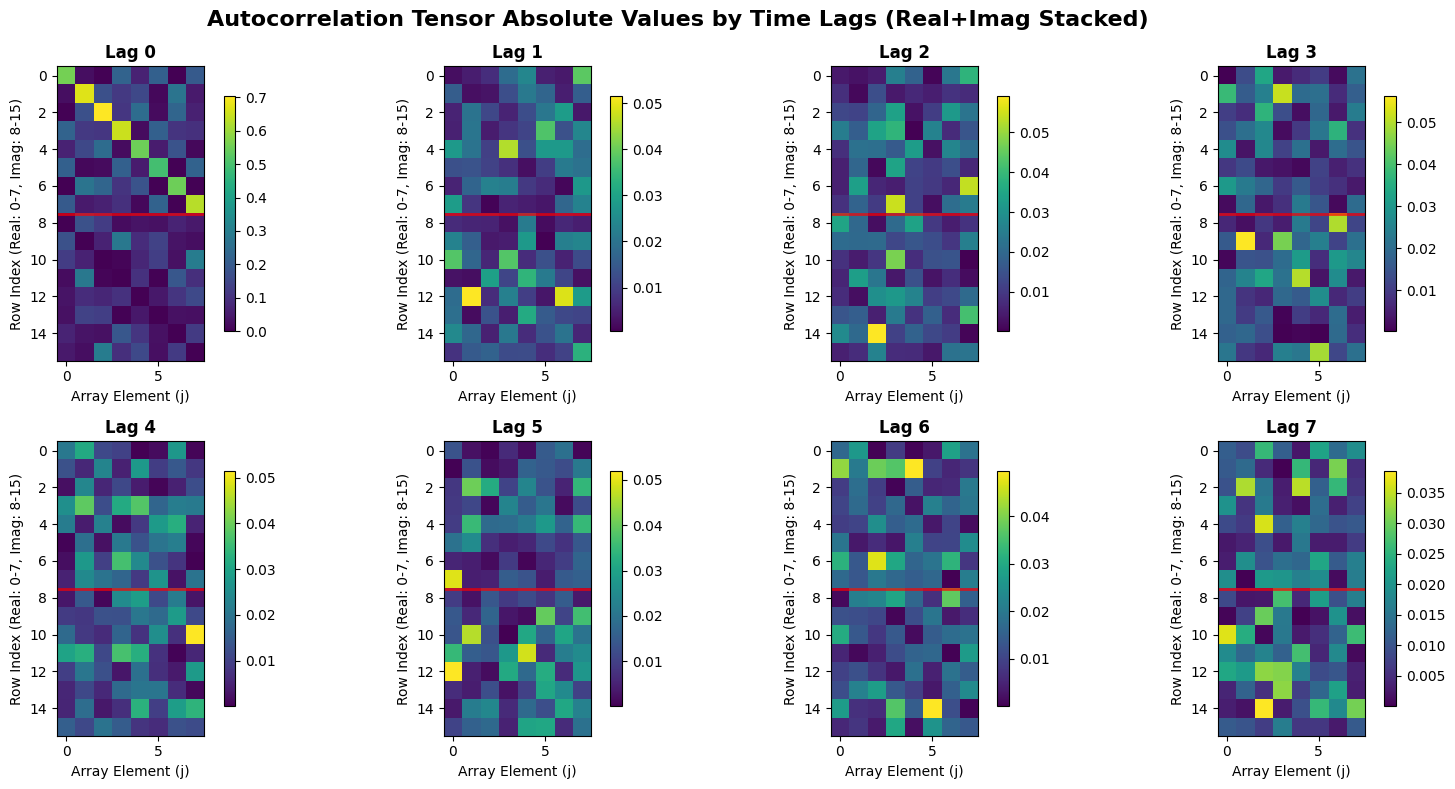


📊 Autocorrelation Statistics by Lag (Full Stacked Matrix):
Lag  Max Abs    Mean Abs   Std Abs    Total Power 
--------------------------------------------------
0    0.704214   0.126373   0.147869   4.842930    
1    0.051655   0.014731   0.010796   0.042694    
2    0.059175   0.016015   0.012065   0.051462    
3    0.056364   0.015941   0.011807   0.050368    
4    0.051531   0.014858   0.010590   0.042614    
5    0.052021   0.015460   0.011659   0.047994    
6    0.049584   0.014936   0.010693   0.043191    
7    0.038580   0.012952   0.009525   0.033083    

📊 Real vs Imaginary Analysis:
Lag  Real Max   Real Mean  Imag Max   Imag Mean 
--------------------------------------------------
0    0.704214   0.172402   0.295797   0.080344  
1    0.045809   0.014454   0.051655   0.015008  
2    0.054363   0.016049   0.059175   0.015982  
3    0.051678   0.014743   0.056364   0.017138  
4    0.038699   0.014767   0.051531   0.014950  
5    0.049531   0.013399   0.052021   0.017521  
6    

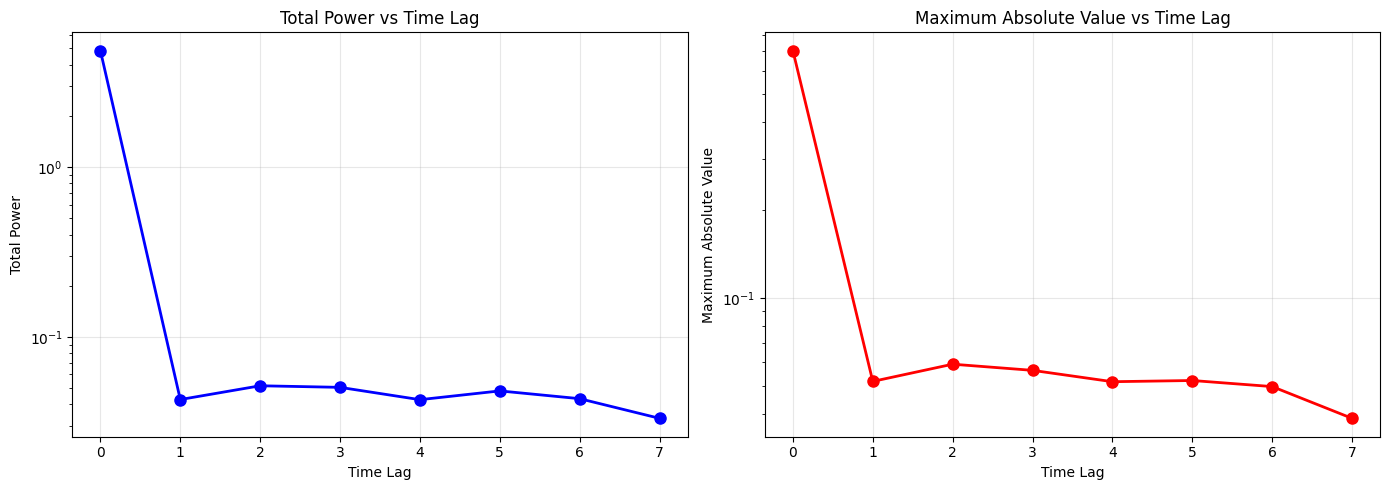

✅ Autocorrelation tensor visualization complete!


In [10]:
# Plot Autocorrelation Tensor Absolute Values by Lags (Full 16x8 Stacked View)
print("📊 Plotting Autocorrelation Tensor by Lags (Real+Imag Stacked)")
print("=" * 60)

if 'autocorr_tensor' in test_sample and autocorr_tensor is not None:
    # Extract autocorrelation tensor
    autocorr_tensor_data = test_sample['autocorr_tensor']  # Shape: [1, tau, 2*M, M]
    
    # Convert to numpy and remove batch dimension
    if isinstance(autocorr_tensor_data, torch.Tensor):
        autocorr_data = autocorr_tensor_data.squeeze(0).numpy()  # Shape: [tau, 2*M, M]
    else:
        autocorr_data = autocorr_tensor_data.squeeze(0)  # Shape: [tau, 2*M, M]
    
    tau, two_M, M = autocorr_data.shape
    
    print(f"📋 Autocorrelation tensor shape: {autocorr_data.shape}")
    print(f"   • Time lags (tau): {tau}")
    print(f"   • Total rows (2*M): {two_M}")
    print(f"   • Array elements (M): {M}")
    
    # Create figure with subplots for each lag
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Autocorrelation Tensor Absolute Values by Time Lags (Real+Imag Stacked)', fontsize=16, fontweight='bold')
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    # Plot each lag separately - show the full 16x8 stacked matrix
    for lag in range(tau):
        ax = axes_flat[lag]
        
        # Get the full stacked matrix for this lag: [2*M, M] = [16, 8]
        stacked_matrix = autocorr_data[lag, :, :]  # Shape: [16, 8]
        
        # Compute absolute values of the stacked matrix
        abs_matrix = np.abs(stacked_matrix)
        
        # Create heatmap
        im = ax.imshow(abs_matrix, cmap='viridis', aspect='equal')
        ax.set_title(f'Lag {lag}', fontweight='bold')
        ax.set_xlabel('Array Element (j)')
        ax.set_ylabel('Row Index (Real: 0-7, Imag: 8-15)')
        
        # Add horizontal line to separate real and imaginary parts
        ax.axhline(y=M-0.5, color='red', linewidth=2, alpha=0.7)
        
        # Add colorbar
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics by lag for the full stacked matrix
    print(f"\n📊 Autocorrelation Statistics by Lag (Full Stacked Matrix):")
    print(f"{'Lag':<4} {'Max Abs':<10} {'Mean Abs':<10} {'Std Abs':<10} {'Total Power':<12}")
    print("-" * 50)
    
    for lag in range(tau):
        stacked_matrix = autocorr_data[lag, :, :]  # Shape: [16, 8]
        abs_matrix = np.abs(stacked_matrix)
        
        max_abs = np.max(abs_matrix)
        mean_abs = np.mean(abs_matrix)
        std_abs = np.std(abs_matrix)
        total_power = np.sum(abs_matrix**2)
        
        print(f"{lag:<4} {max_abs:<10.6f} {mean_abs:<10.6f} {std_abs:<10.6f} {total_power:<12.6f}")
    
    # Additional analysis: Real vs Imaginary parts
    print(f"\n📊 Real vs Imaginary Analysis:")
    print(f"{'Lag':<4} {'Real Max':<10} {'Real Mean':<10} {'Imag Max':<10} {'Imag Mean':<10}")
    print("-" * 50)
    
    for lag in range(tau):
        stacked_matrix = autocorr_data[lag, :, :]  # Shape: [16, 8]
        
        # Real part (first M rows)
        real_part = stacked_matrix[:M, :]  # Shape: [8, 8]
        real_abs = np.abs(real_part)
        real_max = np.max(real_abs)
        real_mean = np.mean(real_abs)
        
        # Imaginary part (last M rows)
        imag_part = stacked_matrix[M:, :]  # Shape: [8, 8]
        imag_abs = np.abs(imag_part)
        imag_max = np.max(imag_abs)
        imag_mean = np.mean(imag_abs)
        
        print(f"{lag:<4} {real_max:<10.6f} {real_mean:<10.6f} {imag_max:<10.6f} {imag_mean:<10.6f}")
    
    # Plot power decay across lags
    print(f"\n📊 Power Decay Analysis:")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Total power per lag
    lag_powers = []
    for lag in range(tau):
        stacked_matrix = autocorr_data[lag, :, :]  # Shape: [16, 8]
        abs_matrix = np.abs(stacked_matrix)
        total_power = np.sum(abs_matrix**2)
        lag_powers.append(total_power)
    
    ax1.plot(range(tau), lag_powers, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Time Lag')
    ax1.set_ylabel('Total Power')
    ax1.set_title('Total Power vs Time Lag')
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # Maximum absolute value per lag
    lag_max_abs = []
    for lag in range(tau):
        stacked_matrix = autocorr_data[lag, :, :]  # Shape: [16, 8]
        abs_matrix = np.abs(stacked_matrix)
        max_abs = np.max(abs_matrix)
        lag_max_abs.append(max_abs)
    
    ax2.plot(range(tau), lag_max_abs, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Time Lag')
    ax2.set_ylabel('Maximum Absolute Value')
    ax2.set_title('Maximum Absolute Value vs Time Lag')
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Autocorrelation tensor visualization complete!")
    
else:
    print("❌ No autocorrelation tensor available for plotting")
    print("   Make sure to run the autocorrelation processing cell first")

## Section 6: UNet Inference

Run the loaded UNet model on the test sample to reconstruct clean covariance matrices:

### UNet Processing Pipeline
1. **Input**: Noisy autocorrelation tensor [1, 8, 16, 8]
2. **Model Forward Pass**: Process through EVDCovarianceReconstructionUNet
3. **Output**: Clean eigenvalues and eigenvectors + reconstructed covariance
4. **Format Conversion**: Convert complex outputs for analysis

### EVD UNet Outputs
- **Eigenvalues**: [batch, M] real positive values (sorted descending)
- **Eigenvectors**: [batch, M, M] complex orthogonal matrix
- **Reconstructed Covariance**: [batch, M, M] complex Hermitian matrix

### Quality Metrics
- Reconstruction error vs original covariance
- Eigenvalue preservation and ordering
- Eigenvector orthogonality verification
- Signal subspace vs noise subspace separation

### Visualization
- Compare input autocorrelation vs output covariance
- Eigenvalue spectrum analysis
- Eigenvector structure visualization

In [11]:
# UNet Inference and Reconstruction
print("🚀 UNet Inference")
print("=" * 30)

if model is not None and autocorr_tensor is not None:
    print(f"📊 Input tensor shape: {autocorr_tensor.shape}")
    print(f"🎯 Model type: EVDCovarianceReconstructionUNet")
    
    # Set model to evaluation mode (should already be set)
    model.eval()
    
    # Run inference
    with torch.no_grad():
        print(f"🔄 Running UNet inference...")
        
        try:
            # Forward pass through EVD UNet
            eigenvals, eigenvecs, reconstructed_cov = model(autocorr_tensor)
            
            print(f"✅ UNet inference completed successfully!")
            print(f"📊 Output shapes:")
            print(f"   • Eigenvalues: {eigenvals.shape}")
            print(f"   • Eigenvectors: {eigenvecs.shape}")
            print(f"   • Reconstructed covariance: {reconstructed_cov.shape}")
            
            # Move outputs to CPU for analysis
            eigenvals_cpu = eigenvals.cpu().numpy().squeeze()  # Remove batch dimension
            eigenvecs_cpu = eigenvecs.cpu().numpy().squeeze()
            reconstructed_cov_cpu = reconstructed_cov.cpu().numpy().squeeze()
            
            print(f"\n📊 Eigenvalue Analysis:")
            print(f"   • Eigenvalues: {eigenvals_cpu}")
            print(f"   • Min eigenvalue: {eigenvals_cpu.min():.6f}")
            print(f"   • Max eigenvalue: {eigenvals_cpu.max():.6f}")
            print(f"   • Condition number: {eigenvals_cpu.max()/eigenvals_cpu.min():.2f}")
            
            # Verify eigenvalues are sorted in descending order
            is_sorted = np.all(eigenvals_cpu[:-1] >= eigenvals_cpu[1:])
            print(f"   • Eigenvalues sorted (descending): {'✅' if is_sorted else '❌'}")
            
            print(f"\n📊 Eigenvector Analysis:")
            # Check orthogonality
            orthogonality_check = eigenvecs_cpu @ eigenvecs_cpu.conj().T
            identity_error = np.mean(np.abs(orthogonality_check - np.eye(M)))
            print(f"   • Orthogonality error: {identity_error:.8f}")
            print(f"   • Eigenvectors orthogonal: {'✅' if identity_error < 1e-4 else '❌'}")
            
            print(f"\n📊 Reconstruction Analysis:")
            # Compare with original noisy covariance
            original_cov = test_sample['covariance_matrix']
            reconstruction_error = np.mean(np.abs(reconstructed_cov_cpu - original_cov))
            print(f"   • Reconstruction error (vs noisy): {reconstruction_error:.6f}")
            
            # Verify EVD reconstruction: R = V * Λ * V^H
            manual_reconstruction = eigenvecs_cpu @ np.diag(eigenvals_cpu) @ eigenvecs_cpu.conj().T
            evd_error = np.mean(np.abs(manual_reconstruction - reconstructed_cov_cpu))
            print(f"   • EVD consistency error: {evd_error:.8f}")
            print(f"   • EVD reconstruction valid: {'✅' if evd_error < 1e-6 else '❌'}")
            
            # Check if matrix is Hermitian
            hermitian_error = np.mean(np.abs(reconstructed_cov_cpu - reconstructed_cov_cpu.conj().T))
            print(f"   • Hermitian error: {hermitian_error:.8f}")
            print(f"   • Matrix is Hermitian: {'✅' if hermitian_error < 1e-6 else '❌'}")
            
            # Store results
            unet_results = {
                'eigenvalues': eigenvals_cpu,
                'eigenvectors': eigenvecs_cpu,
                'reconstructed_covariance': reconstructed_cov_cpu,
                'reconstruction_error': reconstruction_error,
                'orthogonality_error': identity_error,
                'evd_consistency_error': evd_error,
                'hermitian_error': hermitian_error
            }
            
            test_sample['unet_results'] = unet_results
            
            print(f"\n🎯 UNet inference completed successfully!")
            print(f"📊 Reconstruction quality: {'✅ Good' if reconstruction_error < 0.1 else '⚠️ Check quality'}")
            
        except Exception as e:
            print(f"❌ Error during UNet inference: {e}")
            import traceback
            traceback.print_exc()
            unet_results = None
            
else:
    if model is None:
        print("❌ Model not loaded - cannot run inference")
    if autocorr_tensor is None:
        print("❌ Autocorrelation tensor not available - cannot run inference")
    unet_results = None

print(f"🚀 UNet inference section complete!")

🚀 UNet Inference
📊 Input tensor shape: torch.Size([1, 8, 16, 8])
🎯 Model type: EVDCovarianceReconstructionUNet
🔄 Running UNet inference...
✅ UNet inference completed successfully!
📊 Output shapes:
   • Eigenvalues: torch.Size([1, 8])
   • Eigenvectors: torch.Size([1, 8, 8])
   • Reconstructed covariance: torch.Size([1, 8, 8])

📊 Eigenvalue Analysis:
   • Eigenvalues: [1.0587585  0.7321064  0.04284403 0.0157377  0.00785335 0.0062209
 0.         0.        ]
   • Min eigenvalue: 0.000000
   • Max eigenvalue: 1.058758
   • Condition number: inf
   • Eigenvalues sorted (descending): ✅

📊 Eigenvector Analysis:
   • Orthogonality error: 0.00000006
   • Eigenvectors orthogonal: ✅

📊 Reconstruction Analysis:
   • Reconstruction error (vs noisy): 0.148088
   • EVD consistency error: 0.00000000
   • EVD reconstruction valid: ✅
   • Hermitian error: 0.00000001
   • Matrix is Hermitian: ✅

🎯 UNet inference completed successfully!
📊 Reconstruction quality: ⚠️ Check quality
🚀 UNet inference section c

## Section 7: DOA Algorithm Integration

Apply classic DOA algorithms to compare performance with and without UNet denoising:

### DOA Algorithm Comparison
1. **Original Noisy Covariance**: Apply DOA algorithms directly to noisy covariance
2. **UNet Reconstructed Covariance**: Apply DOA algorithms to UNet-denoised covariance
3. **Performance Comparison**: Evaluate accuracy improvement from denoising

### Classic DOA Algorithms
- **MUSIC**: Multiple Signal Classification using eigendecomposition
- **MVDR**: Minimum Variance Distortionless Response beamformer
- **RootMUSIC**: Root-finding variant of MUSIC for linear arrays

### Evaluation Metrics
- **DOA Estimation Error**: Angular error between true and estimated DOAs
- **Detection Rate**: Percentage of correctly detected sources
- **Resolution**: Ability to separate closely spaced sources
- **Robustness**: Performance under noise and multipath conditions

### Expected Results
- UNet denoising should improve DOA estimation accuracy
- Better eigenvalue separation should enhance MUSIC performance
- Reduced noise should improve all algorithm performance

In [12]:
# DOA Algorithm Integration - MUSIC Only
from re import T


print("🎯 DOA Algorithm Integration - MUSIC")
print("=" * 40)

# DOA algorithm parameters
scan_angles = np.arange(30, 151, 1)  # 1-degree resolution from 30° to 150°
num_sources = test_sample['signal_config'].num_sources

print(f"📋 DOA Algorithm Parameters:")
print(f"   • Scan angles: {scan_angles[0]}° to {scan_angles[-1]}° ({len(scan_angles)} points)")
print(f"   • True angles: {test_sample['true_angles']}°")
print(f"   • Number of sources: {num_sources}")

def apply_music_algorithm(covariance_matrix, array_model, scan_angles, num_sources, spatial_smoothing=True, subarray_length=5, label=""):
    """Apply MUSIC algorithm to a covariance matrix and return results"""
    try:
        print(f"🎵 Running MUSIC algorithm {label}...")
        music = MUSIC(
            array_model=array_model,
            scan_angles_deg=scan_angles,
            num_sources=num_sources,
            spatial_smoothing=spatial_smoothing,
            
        )
        music.set_received_covariance(covariance_matrix)
        estimated_angles, spectrum = music.estimate_doa()
        
        print(f"   ✅ MUSIC estimates: {estimated_angles}°")
        
        return {
            'estimated_angles': estimated_angles,
            'spectrum': spectrum,
            'angle_grid': scan_angles
        }
        
    except Exception as e:
        print(f"   ❌ MUSIC failed: {e}")
        return None

# Apply MUSIC to both covariance matrices
if test_sample is not None and 'unet_results' in test_sample:
    print(f"\n🔄 Applying MUSIC to original noisy covariance...")
    original_music = apply_music_algorithm(
        test_sample['covariance_matrix'],
        test_sample['array_model'],
        scan_angles,
        num_sources,
        spatial_smoothing=True,
        subarray_length=5,
        label="(Original)"
    )
    
    print(f"\n🔄 Applying MUSIC to UNet reconstructed covariance...")
    unet_music = apply_music_algorithm(
        test_sample['unet_results']['reconstructed_covariance'],
        test_sample['array_model'],
        scan_angles,
        num_sources,
        spatial_smoothing=True,
        subarray_length=5,
        label="(UNet Denoised)"
    )
    
    # Store results
    test_sample['music_comparison'] = {
        'original': original_music,
        'unet': unet_music,
        'true_angles': test_sample['true_angles'],
        'scan_angles': scan_angles
    }
    
    print(f"\n🎯 MUSIC algorithm integration completed!")
    
else:
    print("❌ Cannot run MUSIC algorithm - missing test sample or UNet results")

print(f"🎵 MUSIC integration section complete!")

🎯 DOA Algorithm Integration - MUSIC
📋 DOA Algorithm Parameters:
   • Scan angles: 30° to 150° (121 points)
   • True angles: [ 90.          35.          37.93137201 344.44793357 164.77185786]°
   • Number of sources: 2

🔄 Applying MUSIC to original noisy covariance...
🎵 Running MUSIC algorithm (Original)...
   ✅ MUSIC estimates: [30.91621835 89.83237092]°

🔄 Applying MUSIC to UNet reconstructed covariance...
🎵 Running MUSIC algorithm (UNet Denoised)...
   ✅ MUSIC estimates: [32.59569297 88.79168491]°

🎯 MUSIC algorithm integration completed!
🎵 MUSIC integration section complete!


📊 MUSIC Spectrum Visualization
📊 Angle breakdown:
   • Main sources: [90. 35.]
   • Multipath: [ 37.93137201 344.44793357 164.77185786]


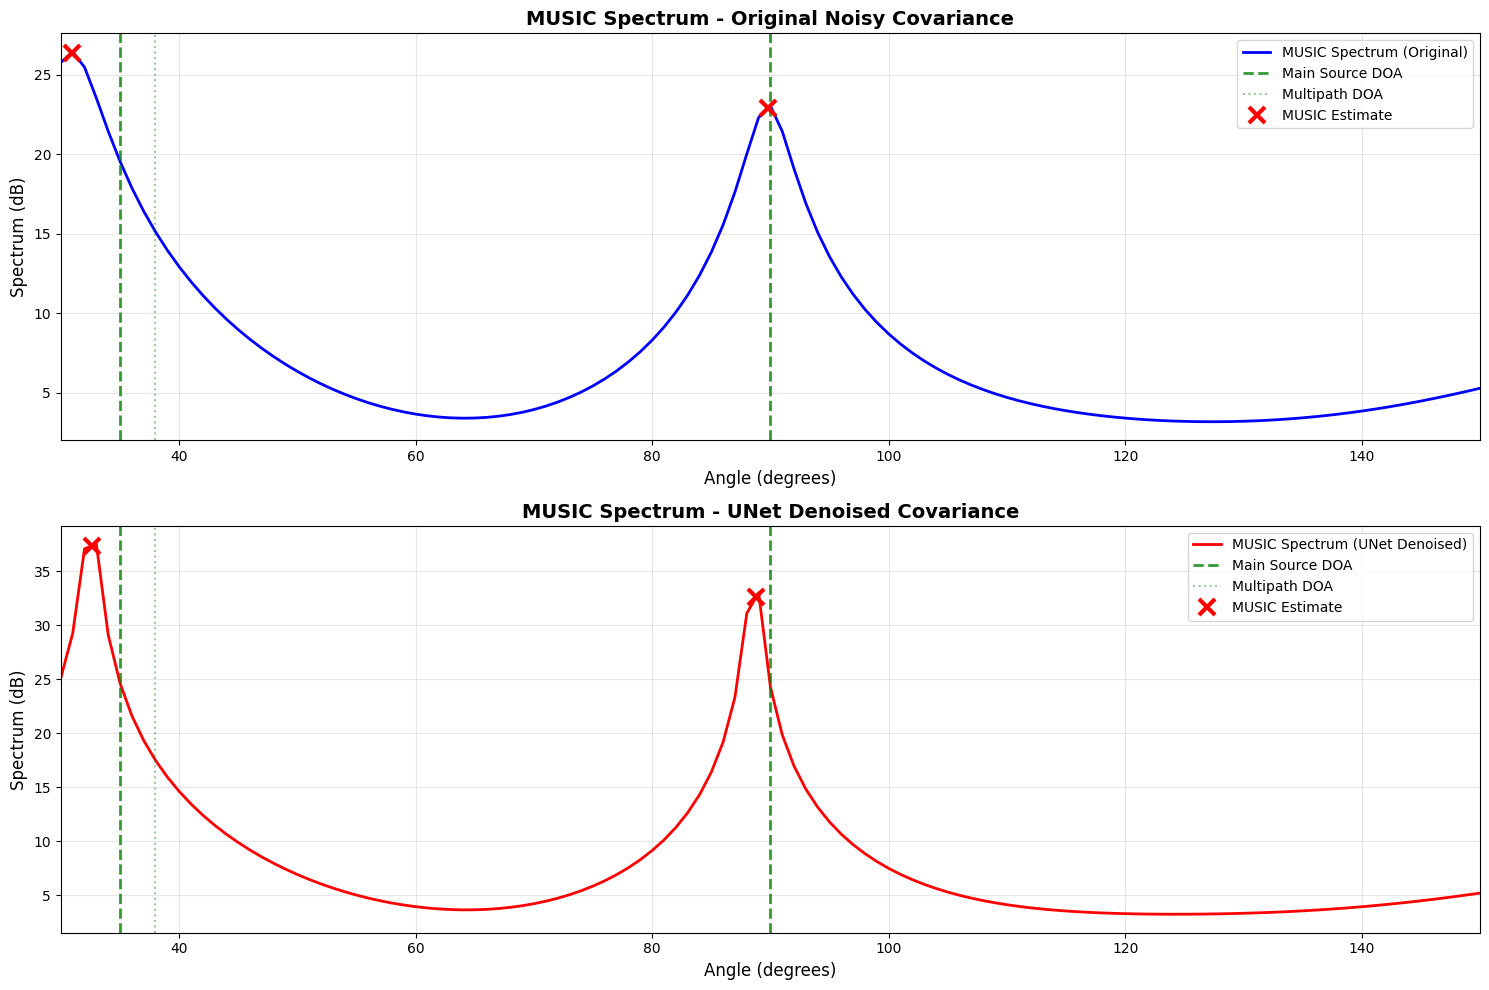


📊 MUSIC DOA Estimation Comparison:
   Main Source DOAs: ['35.0°', '90.0°']
   Multipath DOAs: ['37.9°', '164.8°', '344.4°']
   Original MUSIC: ['30.9°', '89.8°']
   UNet MUSIC: ['32.6°', '88.8°']
   Original RMSE (vs main sources): 2.89°
   UNet RMSE (vs main sources): 1.90°
   Improvement: 0.99° (+34.2%)

📊 Detection Analysis:
   Expected main sources: 2
   Original MUSIC detected: 2
   UNet MUSIC detected: 2
   Total signals (main + multipath): 5
📊 MUSIC spectrum visualization complete!


In [13]:
# Plot MUSIC Spectrum Comparison with Multipath Visualization
print("📊 MUSIC Spectrum Visualization")
print("=" * 35)

if 'music_comparison' in test_sample and test_sample['music_comparison']['original'] is not None:
    
    # Extract data
    original_music = test_sample['music_comparison']['original']
    unet_music = test_sample['music_comparison']['unet']
    
    # Get main source angles (first num_sources angles)
    all_signal_angles = test_sample['signal_config'].angles  # All angles including multipath
    main_source_angles = all_signal_angles[:num_sources]  # Only main sources
    multipath_angles = all_signal_angles[num_sources:] if len(all_signal_angles) > num_sources else []  # Multipath angles
    
    scan_angles = test_sample['music_comparison']['scan_angles']
    
    print(f"📊 Angle breakdown:")
    print(f"   • Main sources: {main_source_angles}")
    print(f"   • Multipath: {multipath_angles}")
    
    # Create comparison plot
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Original MUSIC spectrum
    plt.subplot(2, 1, 1)
    if original_music is not None:
        plt.plot(scan_angles, 10*np.log10(np.abs(original_music['spectrum']) + 1e-10), 
                'b-', linewidth=2, label='MUSIC Spectrum (Original)')
        
        # Plot main source DOAs as solid green vertical lines
        for i, doa in enumerate(main_source_angles):
            if 30 <= doa <= 150:  # Within scan range
                plt.axvline(x=doa, color='green', linestyle='--', linewidth=2, 
                           alpha=0.8, label='Main Source DOA' if i == 0 else "")
        
        # Plot multipath DOAs as transparent green vertical lines
        for i, doa in enumerate(multipath_angles):
            if 30 <= doa <= 150:  # Within scan range
                plt.axvline(x=doa, color='green', linestyle=':', linewidth=1.5, 
                           alpha=0.4, label='Multipath DOA' if i == 0 else "")
        
        # Plot MUSIC estimates as red X markers
        for i, est_doa in enumerate(original_music['estimated_angles']):
            if 30 <= est_doa <= 150:  # Within scan range
                spectrum_val = np.interp(est_doa, scan_angles, 
                                       10*np.log10(np.abs(original_music['spectrum']) + 1e-10))
                plt.plot(est_doa, spectrum_val, 'rx', markersize=12, markeredgewidth=3,
                        label='MUSIC Estimate' if i == 0 else "")
    
    plt.xlabel('Angle (degrees)', fontsize=12)
    plt.ylabel('Spectrum (dB)', fontsize=12)
    plt.title('MUSIC Spectrum - Original Noisy Covariance', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.xlim(30, 150)
    
    # Plot 2: UNet MUSIC spectrum
    plt.subplot(2, 1, 2)
    if unet_music is not None:
        plt.plot(scan_angles, 10*np.log10(np.abs(unet_music['spectrum']) + 1e-10), 
                'r-', linewidth=2, label='MUSIC Spectrum (UNet Denoised)')
        
        # Plot main source DOAs as solid green vertical lines
        for i, doa in enumerate(main_source_angles):
            if 30 <= doa <= 150:  # Within scan range
                plt.axvline(x=doa, color='green', linestyle='--', linewidth=2, 
                           alpha=0.8, label='Main Source DOA' if i == 0 else "")
        
        # Plot multipath DOAs as transparent green vertical lines
        for i, doa in enumerate(multipath_angles):
            if 30 <= doa <= 150:  # Within scan range
                plt.axvline(x=doa, color='green', linestyle=':', linewidth=1.5, 
                           alpha=0.4, label='Multipath DOA' if i == 0 else "")
        
        # Plot MUSIC estimates as red X markers
        for i, est_doa in enumerate(unet_music['estimated_angles']):
            if 30 <= est_doa <= 150:  # Within scan range
                spectrum_val = np.interp(est_doa, scan_angles, 
                                       10*np.log10(np.abs(unet_music['spectrum']) + 1e-10))
                plt.plot(est_doa, spectrum_val, 'rx', markersize=12, markeredgewidth=3,
                        label='MUSIC Estimate' if i == 0 else "")
    
    plt.xlabel('Angle (degrees)', fontsize=12)
    plt.ylabel('Spectrum (dB)', fontsize=12)
    plt.title('MUSIC Spectrum - UNet Denoised Covariance', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.xlim(30, 150)
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison results
    print(f'\n📊 MUSIC DOA Estimation Comparison:')
    print(f'   Main Source DOAs: {[f"{doa:.1f}°" for doa in sorted(main_source_angles)]}')
    if len(multipath_angles) > 0:
        print(f'   Multipath DOAs: {[f"{doa:.1f}°" for doa in sorted(multipath_angles)]}')
    
    if original_music is not None:
        orig_sorted = sorted(original_music['estimated_angles'])
        print(f'   Original MUSIC: {[f"{est:.1f}°" for est in orig_sorted]}')
    
    if unet_music is not None:
        unet_sorted = sorted(unet_music['estimated_angles'])
        print(f'   UNet MUSIC: {[f"{est:.1f}°" for est in unet_sorted]}')
    
    # Calculate simple errors (comparing only against main sources)
    if original_music is not None and unet_music is not None:
        main_sorted = sorted(main_source_angles)
        orig_sorted = sorted(original_music['estimated_angles'])
        unet_sorted = sorted(unet_music['estimated_angles'])
        
        if len(orig_sorted) == len(main_sorted):
            orig_errors = [abs(t - e) for t, e in zip(main_sorted, orig_sorted)]
            orig_rmse = np.sqrt(np.mean(np.array(orig_errors)**2))
            print(f'   Original RMSE (vs main sources): {orig_rmse:.2f}°')
        
        if len(unet_sorted) == len(main_sorted):
            unet_errors = [abs(t - e) for t, e in zip(main_sorted, unet_sorted)]
            unet_rmse = np.sqrt(np.mean(np.array(unet_errors)**2))
            print(f'   UNet RMSE (vs main sources): {unet_rmse:.2f}°')
            
            if len(orig_sorted) == len(main_sorted):
                improvement = orig_rmse - unet_rmse
                improvement_pct = (improvement / orig_rmse) * 100 if orig_rmse > 0 else 0
                print(f'   Improvement: {improvement:.2f}° ({improvement_pct:+.1f}%)')
        
        print(f'\n📊 Detection Analysis:')
        print(f'   Expected main sources: {len(main_sorted)}')
        print(f'   Original MUSIC detected: {len(orig_sorted)}')
        print(f'   UNet MUSIC detected: {len(unet_sorted)}')
        if len(multipath_angles) > 0:
            print(f'   Total signals (main + multipath): {len(main_sorted) + len(multipath_angles)}')
    
else:
    print("❌ No MUSIC results available for plotting")

print(f"📊 MUSIC spectrum visualization complete!")

In [60]:
# Dataset Generation for Testing (In-Memory)
print("🚀 Dataset Generation for UNet Testing")
print("=" * 45)

# =====================================================
# DATASET CONFIGURATION - Based on training notebook
# =====================================================

# === PARAMETER RANGES ===
angles_deg = list(range(30, 151, 1))
snr_db = list(range(-20, 21, 5))
num_snapshots = [512]  # Fixed snapshot length
num_sources = [
    [1, 0],  # 1 main + 0 interference
    # [1, 1],  # 1 main + 1 interference  
    # [1, 2],  # 1 main + 2 interference
]
sir_db = [0]  # Single SIR level
num_multipath = [6]  # No multipath, 1 multipath, 2 multipath
array_imperfections = [True]  # Perfect and imperfect arrays

# === GENERATION CONTROL ===
examples_per_combination = 10  # Small number for testing
dataset_name = "UNet_Testing_dataset"

# === ARRAY CONFIGURATION ===
array_type = "linear"
num_elements = 8
carrier_freq = 2.45e9
sampling_freq = 1e6

# === OUTPUT CONTROL ===
save_received_signal = True
save_covariance_matrix = True
save_clean_covariance_matrix = True  # CRITICAL for UNet targets
save_autocorrelation_matrix = True  # CRITICAL for UNet inputs
save_music_estimates = False
save_steering_vectors = True
save_array_metadata = False

# === AUTOCORRELATION CONTROL ===
autocorr_tau = 8  # Must match UNet training

# === ANGLE SEPARATION CONTROL ===
min_angle_separation_deg = 10.0

print("📋 Testing Dataset Configuration:")
print(f"   • Array Type: {array_type} with {num_elements} elements")
print(f"   • Angles: {angles_deg}")
print(f"   • SNR levels: {snr_db} dB")
print(f"   • Source configurations: {num_sources}")
print(f"   • Multipath components: {num_multipath}")
print(f"   • Array imperfections: {array_imperfections}")
print(f"   • Examples per combination: {examples_per_combination}")

# Create the configuration object
test_config = SimpleDatasetConfig(
    # Parameter ranges
    angles_deg=angles_deg,
    snr_db=snr_db,
    num_snapshots=num_snapshots,
    num_sources=num_sources,
    sir_db=sir_db,
    num_multipath=num_multipath,
    array_imperfections=array_imperfections,
    
    # Random sampling control
    random_sampling_mode=False,
    random_sample_params=None,
    
    # Generation control
    examples_per_combination=examples_per_combination,
    dataset_name=dataset_name,
    
    # Array configuration
    array_type=array_type,
    num_elements=num_elements,
    carrier_freq=carrier_freq,
    sampling_freq=sampling_freq,
    
    # Output control
    save_received_signal=save_received_signal,
    save_covariance_matrix=save_covariance_matrix,
    save_clean_covariance_matrix=save_clean_covariance_matrix,
    save_autocorrelation_matrix=save_autocorrelation_matrix,
    save_music_estimates=save_music_estimates,
    save_steering_vectors=save_steering_vectors,
    save_array_metadata=save_array_metadata,
    
    # Autocorrelation control
    autocorr_tau=autocorr_tau,
    
    # MUSIC algorithm control
    # music_angle_grid_deg=list(range(0, 181, 1)),
    # music_num_sources=None,
    
    # Angle separation control
    min_angle_separation_deg=min_angle_separation_deg
)

print(f"\n🔧 Configuration Created Successfully!")
print(f"📊 Total parameter combinations: {test_config.get_total_combinations()}")
print(f"📈 Total samples to generate: {test_config.get_total_samples()}")

# Generate the testing dataset
print("🚀 Starting UNet testing dataset generation...")
print("⏳ This may take a few minutes depending on the configuration size.")

# Create dataset generator with a fixed seed for reproducibility
test_generator = ControlledDatasetGenerator(test_config, seed=np.random.randint(0, 1000000))

# Generate the dataset (will be saved in Data/datasets/{array_type}/{dataset_name}/)
output_dir = "Data/datasets"
test_dataset_file = test_generator.generate_dataset(output_dir)

print(f"\n✅ Testing dataset generation completed!")
print(f"📁 Dataset saved to: {test_dataset_file}")

# Save the dataset path for later use
test_dataset_path = test_dataset_file
print(f"🔗 Dataset path stored in variable 'test_dataset_path'")

# Try to load and display basic information about the generated dataset
try:
    # Load the dataset to verify it was created correctly
    test_dataset = DOADataset(test_dataset_path)
    print(f"\n📊 Dataset Verification:")
    print(f"   - Total samples: {len(test_dataset)}")
    print(f"   - Available data components:")
    print(f"     • Received signals: {test_dataset.has_received_signal}")
    print(f"     • Covariance matrices: {test_dataset.has_covariance}")
    print(f"     • Clean covariance matrices: {test_dataset.has_clean_covariance}")
    print(f"     • Autocorrelation matrices: {test_dataset.has_autocorrelation}")
    print(f"     • MUSIC estimates: {test_dataset.has_music_estimates}")
    print(f"     • Steering vectors: {test_dataset.has_steering}")
    print(f"     • Array models: {test_dataset.has_array_models}")
    
    # Show label summary
    print(f"\n📋 Label Summary:")
    label_summary = test_dataset.get_label_summary()
    for label, summary in label_summary.items():
        print(f"   - {label}: {summary}")
    
    # Show first sample details
    if len(test_dataset) > 0:
        first_sample = test_dataset[0]
        print(f"\n📊 First Sample Details:")
        labels = first_sample['labels']
        print(f"   - DOAs: {labels['doas']}°")
        print(f"   - SNR: {labels['snr']} dB")
        print(f"   - Sources: {labels['num_sources']} [main, interference]")
        print(f"   - Multipath: {labels['num_multipath']}")
        print(f"   - Array imperfections: {labels['array_imperfections']}")
        
        # Show data shapes
        if 'autocorrelation_matrix' in first_sample:
            print(f"   - Autocorr matrix shape: {first_sample['autocorrelation_matrix'].shape}")
        if 'clean_covariance_matrix' in first_sample:
            print(f"   - Clean covariance shape: {first_sample['clean_covariance_matrix'].shape}")
        if 'covariance_matrix' in first_sample:
            print(f"   - Noisy covariance shape: {first_sample['covariance_matrix'].shape}")
        
except Exception as e:
    print(f"⚠️ Error loading dataset for verification: {e}")
    print("The dataset file was created but there may be an issue with the format.")
    test_dataset = None

print("\n🎉 Testing dataset generation section completed!")
print(f"🎯 Dataset ready for UNet batch testing!")

🚀 Dataset Generation for UNet Testing
📋 Testing Dataset Configuration:
   • Array Type: linear with 8 elements
   • Angles: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150]
   • SNR levels: [-20, -15, -10, -5, 0, 5, 10, 15, 20] dB
   • Source configurations: [[1, 0]]
   • Multipath components: [6]
   • Array imperfections: [True]
   • Examples per combination: 10

🔧 Configuration Created Successfully!
📊 Total parameter combinations: 1089
📈 Total samples to generate: 10890
🚀 Starting UNet testing dataset gene

Parameter combinations: 100%|██████████| 1089/1089 [00:43<00:00, 25.02it/s]


Dataset generated successfully!
Dataset file: /Users/itamaralmog/Documents/Masters/Second Year/All_DOA_nets/Tri4Net/Data/datasets/linear/UNet_Testing_dataset/UNet_Testing_dataset.h5
Info file: /Users/itamaralmog/Documents/Masters/Second Year/All_DOA_nets/Tri4Net/Data/datasets/linear/UNet_Testing_dataset/UNet_Testing_dataset_info.json

✅ Testing dataset generation completed!
📁 Dataset saved to: /Users/itamaralmog/Documents/Masters/Second Year/All_DOA_nets/Tri4Net/Data/datasets/linear/UNet_Testing_dataset/UNet_Testing_dataset.h5
🔗 Dataset path stored in variable 'test_dataset_path'

📊 Dataset Verification:
   - Total samples: 10890
   - Available data components:
     • Received signals: True
     • Covariance matrices: True
     • Clean covariance matrices: True
     • Autocorrelation matrices: True
     • MUSIC estimates: False
     • Steering vectors: True
     • Array models: False

📋 Label Summary:
   - array_imperfections: True: 10890, False: 0
   - doas: Total DOAs: 76230, Range: 

In [61]:
def create_autocorrelation_input_for_unet(sample, tau=8, device='cpu'):
    """
    Convert a sample from the filtered dataset to UNet-compatible autocorrelation tensor.
    
    Args:
        sample: Sample from filtered dataset containing 'received_signal'
        tau: Number of autocorrelation lags (default: 8, matching UNet training)
        device: Device to create tensors on
    
    Returns:
        torch.Tensor: Autocorrelation tensor [tau, 2M, M] ready for UNet input
    """
    # Extract received signal from sample
    received_signal = sample['received_signal']  # Should be complex array [M, T]
    
    # Convert to torch tensor if needed
    if not isinstance(received_signal, torch.Tensor):
        received_signal = torch.tensor(received_signal, dtype=torch.complex64)
    
    # Move to specified device
    received_signal = received_signal.to(device)
    
    # Get dimensions
    M, T = received_signal.shape
    
    # Create autocorrelation tensor using the same method as in UNet dataset
    autocorr_tensor = torch.zeros(tau, 2*M, M, dtype=torch.float32, device=device)
    
    # Compute autocorrelation for each lag
    max_lag = min(tau, T - 1)
    
    for lag in range(max_lag):
        samples_available = T - lag
        if samples_available > 0:
            # Compute cross-correlation matrix for this lag
            x1 = received_signal[:, :samples_available]  # [M, samples_available]
            x2 = received_signal[:, lag:lag + samples_available]  # [M, samples_available]
            
            # Compute R(lag) = (1/N) * x1 @ x2^H
            R_lag = torch.matmul(x1, x2.conj().T) / samples_available  # [M, M]
            
            # Store real and imaginary parts
            autocorr_tensor[lag, :M, :] = R_lag.real
            autocorr_tensor[lag, M:, :] = R_lag.imag
    
    return autocorr_tensor

def apply_music_to_covariance(covariance_matrix, array_model, scan_angles, num_sources):
    """
    Apply MUSIC algorithm to a covariance matrix and return DOA estimates.
    
    Args:
        covariance_matrix: Complex covariance matrix
        array_model: Array model for steering vectors
        scan_angles: Angle grid for MUSIC spectrum
        num_sources: Number of sources to detect
    
    Returns:
        estimated_angles: MUSIC DOA estimates in degrees
    """
    try:
        music = MUSIC(
            array_model=array_model,
            scan_angles_deg=scan_angles,
            num_sources=num_sources
        )
        music.set_received_covariance(covariance_matrix)
        estimated_angles, _ = music.estimate_doa()
        return estimated_angles
    except Exception as e:
        print(f"   ⚠️ MUSIC failed: {e}")
        return np.array([])

def calculate_doa_rmse(true_angles, estimated_angles):
    """
    Calculate RMSE between true and estimated DOA angles.
    
    Args:
        true_angles: True DOA angles
        estimated_angles: Estimated DOA angles
    
    Returns:
        rmse: Root mean square error in degrees
    """
    if len(estimated_angles) == 0:
        return np.inf
    
    true_angles = np.array(true_angles)
    estimated_angles = np.array(estimated_angles)
    
    # Handle different number of estimates vs true sources
    min_sources = min(len(true_angles), len(estimated_angles))
    
    if min_sources == 0:
        return np.inf
    
    # Simple pairing: sort both and match closest
    true_sorted = np.sort(true_angles[:min_sources])
    est_sorted = np.sort(estimated_angles[:min_sources])
    
    # Calculate RMSE
    errors = np.abs(true_sorted - est_sorted)
    rmse = np.sqrt(np.mean(errors**2))
    
    return rmse

def evaluate_unet_doa_performance_by_snr(dataset, model, device, tau=8, max_samples_per_snr=50):
    """
    Comprehensive UNet evaluation based on MUSIC DOA estimation performance across SNR levels.
    
    Args:
        dataset: DOADataset object
        model: Trained UNet model
        device: Device for computation
        tau: Number of autocorrelation lags
        max_samples_per_snr: Maximum samples to evaluate per SNR level
    
    Returns:
        dict: Results organized by SNR level
    """
    print("🚀 Starting UNet DOA Performance Evaluation by SNR")
    print("=" * 60)
    
    # MUSIC parameters
    scan_angles = np.arange(30, 151, 1)  # 1-degree resolution
    
    # Get all unique SNR values in the dataset
    all_snr_values = []
    for i in range(len(dataset)):
        sample = dataset[i]
        snr_value = float(sample['labels']['snr'])
        if snr_value not in all_snr_values:
            all_snr_values.append(snr_value)
    
    all_snr_values = sorted(all_snr_values)
    print(f"📊 Found SNR levels: {all_snr_values}")
    
    # Set model to evaluation mode
    model.eval()
    
    # Results storage
    results_by_snr = {}
    
    # Evaluate each SNR level
    for snr_db in all_snr_values:
        print(f"\n🎯 Evaluating SNR = {snr_db} dB")
        print("-" * 40)
        
        # Filter dataset for this SNR
        filtered_dataset = dataset.filter(snr=snr_db)
        print(f"📊 Found {len(filtered_dataset)} samples at {snr_db} dB SNR")
        
        if len(filtered_dataset) == 0:
            continue
        
        # Limit samples for computational efficiency
        num_samples = max(len(filtered_dataset), max_samples_per_snr)
        print(f"🔄 Processing {num_samples} samples...")
        
        # Storage for this SNR level
        noisy_music_rmse_list = []
        reconstructed_music_rmse_list = []
        sample_info = []
        
        # Process samples
        for idx in range(num_samples):
            try:
                sample = filtered_dataset[idx]
                
                # Get true DOA angles (only main sources, not multipath)
                labels = sample['labels']
                all_doas = labels['doas']
                num_main_sources = labels['num_sources'].sum()  # [main, interference]
                true_angles = all_doas[:num_main_sources]  # Only main sources
                
                # Get noisy covariance
                noisy_cov = sample['covariance_matrix']
                if isinstance(noisy_cov, torch.Tensor):
                    noisy_cov = noisy_cov.numpy()
                
                # Create array model (we need this for MUSIC)
                # For simplicity, create a basic array model
                from src.signalgen.array_processing import ArrayConfig, ArrayModel
                array_config_basic = ArrayConfig(
                    array_type='linear',
                    num_elements=8,
                    carrier_freq=2.45e9,
                    element_spacing=0.5
                )
                array_model = ArrayModel(array_config_basic)
                
                # Apply MUSIC to noisy covariance
                noisy_music_estimates = apply_music_to_covariance(
                    noisy_cov, array_model, scan_angles, num_main_sources
                )
                noisy_music_rmse = calculate_doa_rmse(true_angles, noisy_music_estimates)
                noisy_music_rmse_list.append(noisy_music_rmse)
                
                # Create UNet input and run inference
                # unet_input = create_autocorrelation_input_for_unet(sample, tau=tau, device=device)
                unet_input = sample['autocorrelation_matrix']
                unet_input_batch = unet_input.unsqueeze(0)  # Add batch dimension
                
                # UNet inference
                with torch.no_grad():
                    eigenvals, eigenvecs, reconstructed_cov = model(unet_input_batch)
                    reconstructed_cov_np = reconstructed_cov.cpu().numpy().squeeze()
                
                # Apply MUSIC to reconstructed covariance
                reconstructed_music_estimates = apply_music_to_covariance(
                    reconstructed_cov_np, array_model, scan_angles, num_main_sources
                )
                reconstructed_music_rmse = calculate_doa_rmse(true_angles, reconstructed_music_estimates)
                reconstructed_music_rmse_list.append(reconstructed_music_rmse)
                
                # Store sample information
                sample_info.append({
                    'true_angles': true_angles,
                    'num_sources': labels['num_sources'],
                    'num_multipath': labels['num_multipath'],
                    'array_imperfections': labels['array_imperfections'],
                    'noisy_music_estimates': noisy_music_estimates,
                    'reconstructed_music_estimates': reconstructed_music_estimates,
                    'noisy_music_rmse': noisy_music_rmse,
                    'reconstructed_music_rmse': reconstructed_music_rmse,
                    'improvement': noisy_music_rmse - reconstructed_music_rmse
                })
                
            except Exception as e:
                print(f"   ⚠️ Error processing sample {idx}: {e}")
                continue
        
        # Calculate statistics for this SNR level
        if noisy_music_rmse_list and reconstructed_music_rmse_list:
            # Filter out infinite values
            valid_indices = [(i, n, r) for i, (n, r) in enumerate(zip(noisy_music_rmse_list, reconstructed_music_rmse_list)) 
                           if not np.isinf(n) and not np.isinf(r)]
            
            if valid_indices:
                valid_noisy = [n for _, n, r in valid_indices]
                valid_reconstructed = [r for _, n, r in valid_indices]
                
                noisy_rmse_avg = np.mean(valid_noisy)
                reconstructed_rmse_avg = np.mean(valid_reconstructed)
                improvement = noisy_rmse_avg - reconstructed_rmse_avg
                improvement_pct = (improvement / noisy_rmse_avg) * 100 if noisy_rmse_avg > 0 else 0
                
                results_by_snr[snr_db] = {
                    'num_samples': len(valid_indices),
                    'noisy_music_rmse': noisy_rmse_avg,
                    'reconstructed_music_rmse': reconstructed_rmse_avg,
                    'improvement_absolute': improvement,
                    'improvement_percentage': improvement_pct,
                    'noisy_rmse_list': valid_noisy,
                    'reconstructed_rmse_list': valid_reconstructed,
                    'sample_details': sample_info
                }
                
                print(f"   ✅ Results for SNR {snr_db} dB:")
                print(f"      • Noisy MUSIC RMSE: {noisy_rmse_avg:.2f}°")
                print(f"      • UNet MUSIC RMSE: {reconstructed_rmse_avg:.2f}°")
                print(f"      • Improvement: {improvement:.2f}° ({improvement_pct:+.1f}%)")
                print(f"      • Valid samples: {len(valid_indices)}/{len(noisy_music_rmse_list)}")
    
    return results_by_snr

def display_doa_evaluation_summary(results_by_snr):
    """Display a summary table of DOA evaluation results"""
    print("\n📊 UNet DOA Performance Evaluation Summary")
    print("=" * 90)
    print(f"{'SNR (dB)':<10} {'Samples':<10} {'Noisy MUSIC':<15} {'UNet MUSIC':<15} {'Improvement':<15} {'Improvement %':<15}")
    print(f"{'':^10} {'':^10} {'RMSE (°)':<15} {'RMSE (°)':<15} {'(°)':<15} {'':^15}")
    print("-" * 90)
    
    for snr_db in sorted(results_by_snr.keys()):
        results = results_by_snr[snr_db]
        print(f"{snr_db:<10.1f} {results['num_samples']:<10} {results['noisy_music_rmse']:<15.2f} "
              f"{results['reconstructed_music_rmse']:<15.2f} {results['improvement_absolute']:<15.2f} "
              f"{results['improvement_percentage']:<15.1f}")
    
    # Overall statistics
    all_improvements = [results['improvement_percentage'] for results in results_by_snr.values()]
    if all_improvements:
        avg_improvement = np.mean(all_improvements)
        print("-" * 90)
        print(f"Average DOA Improvement: {avg_improvement:.1f}%")
        print(f"Best SNR for UNet: {max(results_by_snr.keys(), key=lambda x: results_by_snr[x]['improvement_percentage']):.1f} dB")
        print(f"Worst SNR for UNet: {min(results_by_snr.keys(), key=lambda x: results_by_snr[x]['improvement_percentage']):.1f} dB")

print("✅ Fixed UNet DOA evaluation functions defined!")
print("🎯 Now evaluating based on MUSIC DOA estimation performance!")

✅ Fixed UNet DOA evaluation functions defined!
🎯 Now evaluating based on MUSIC DOA estimation performance!


In [62]:
# Run comprehensive UNet evaluation
if model is not None and test_dataset is not None:
    print("🚀 Running Comprehensive UNet Evaluation...")
    
    # Run evaluation across all SNR levels
    evaluation_results = evaluate_unet_doa_performance_by_snr(
        dataset=test_dataset,
        model=model,
        device=device,
        tau=8,
        max_samples_per_snr=20  # Limit samples for faster evaluation
    )
    
    # Display summary
    display_doa_evaluation_summary(evaluation_results)
    
    # Store results for further analysis
    print(f"\n💾 Results stored in 'evaluation_results' variable")
    print(f"🎯 Comprehensive evaluation completed!")
    
else:
    print("❌ Cannot run evaluation - missing model or dataset")
    evaluation_results = None

🚀 Running Comprehensive UNet Evaluation...
🚀 Starting UNet DOA Performance Evaluation by SNR
📊 Found SNR levels: [-20.0, -15.0, -10.0, -5.0, 0.0, 5.0, 10.0, 15.0, 20.0]

🎯 Evaluating SNR = -20.0 dB
----------------------------------------
📊 Found 1210 samples at -20.0 dB SNR
🔄 Processing 1210 samples...
   ✅ Results for SNR -20.0 dB:
      • Noisy MUSIC RMSE: 38.52°
      • UNet MUSIC RMSE: 39.34°
      • Improvement: -0.83° (-2.1%)
      • Valid samples: 1210/1210

🎯 Evaluating SNR = -15.0 dB
----------------------------------------
📊 Found 1210 samples at -15.0 dB SNR
🔄 Processing 1210 samples...
   ✅ Results for SNR -15.0 dB:
      • Noisy MUSIC RMSE: 34.90°
      • UNet MUSIC RMSE: 37.18°
      • Improvement: -2.28° (-6.5%)
      • Valid samples: 1210/1210

🎯 Evaluating SNR = -10.0 dB
----------------------------------------
📊 Found 1210 samples at -10.0 dB SNR
🔄 Processing 1210 samples...
   ✅ Results for SNR -10.0 dB:
      • Noisy MUSIC RMSE: 22.24°
      • UNet MUSIC RMSE: 22.4

In [63]:
def plot_doa_rmse_vs_snr(evaluation_results, save_path=None):
    """
    Plot DOA RMSE vs SNR comparison between noisy and UNet-reconstructed covariance matrices.
    
    Args:
        evaluation_results: Results dictionary from evaluate_unet_doa_performance_by_snr
        save_path: Optional path to save the plot
    """
    if not evaluation_results:
        print("❌ No evaluation results to plot")
        return
    
    # Extract data for plotting
    snr_values = sorted(evaluation_results.keys())
    noisy_rmse_values = [evaluation_results[snr]['noisy_music_rmse'] for snr in snr_values]
    unet_rmse_values = [evaluation_results[snr]['reconstructed_music_rmse'] for snr in snr_values]
    improvement_pct = [evaluation_results[snr]['improvement_percentage'] for snr in snr_values]
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: DOA RMSE Comparison
    ax1.plot(snr_values, noisy_rmse_values, 'b-o', linewidth=2, markersize=8, 
             label='MUSIC with Noisy Covariance', alpha=0.8)
    ax1.plot(snr_values, unet_rmse_values, 'r-s', linewidth=2, markersize=8, 
             label='MUSIC with UNet Denoised Covariance', alpha=0.8)
    
    ax1.set_xlabel('SNR (dB)', fontsize=12)
    ax1.set_ylabel('DOA RMSE (degrees)', fontsize=12)
    ax1.set_title('MUSIC DOA Estimation Performance vs SNR', fontsize=14, fontweight='bold')
    # ax1.grid(True, alpha=0.3)
    ax1.grid(True, alpha=0.3, which='major')
    ax1.grid(True, alpha=0.2, which='minor', linestyle='--')
    ax1.minorticks_on()
    ax1.legend(fontsize=11)
    ax1.set_yscale('log')
    # Add sample count annotations
    for i, snr in enumerate(snr_values):
        num_samples = evaluation_results[snr]['num_samples']
        ax1.annotate(f'n={num_samples}', 
                    xy=(snr, unet_rmse_values[i]), 
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, alpha=0.7)
    
    # Plot 2: Improvement Percentage
    colors = ['green' if imp > 0 else 'red' for imp in improvement_pct]
    bars = ax2.bar(snr_values, improvement_pct, color=colors, alpha=0.7, 
                   edgecolor='black', linewidth=1)
    
    ax2.set_xlabel('SNR (dB)', fontsize=12)
    ax2.set_ylabel('DOA Improvement (%)', fontsize=12)
    ax2.set_title('UNet Denoising DOA Improvement vs SNR', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # Add value labels on bars
    for bar, imp_val in zip(bars, improvement_pct):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + (1 if height >= 0 else -3),
                f'{imp_val:.1f}%', ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=10, fontweight='bold')
    
    # Add summary statistics
    avg_improvement = np.mean(improvement_pct)
    best_snr = snr_values[np.argmax(improvement_pct)]
    worst_snr = snr_values[np.argmin(improvement_pct)]
    
    # Add text box with statistics
    stats_text = f"""DOA Performance Summary:
• Average Improvement: {avg_improvement:.1f}%
• Best SNR: {best_snr:.1f} dB ({max(improvement_pct):.1f}%)
• Worst SNR: {worst_snr:.1f} dB ({min(improvement_pct):.1f}%)
• Total Samples: {sum(evaluation_results[snr]['num_samples'] for snr in snr_values)}"""
    
    ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    
    # Save plot if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📁 Plot saved to: {save_path}")
    
    plt.show()
    
    # Print numerical summary
    print(f"\n📊 DOA Performance Numerical Summary:")
    print(f"{'SNR (dB)':<10} {'Noisy MUSIC':<15} {'UNet MUSIC':<15} {'Improvement':<12}")
    print(f"{'':^10} {'RMSE (°)':<15} {'RMSE (°)':<15} {'(%)':<12}")
    print("-" * 60)
    for snr, noisy_rmse, unet_rmse, imp in zip(snr_values, noisy_rmse_values, unet_rmse_values, improvement_pct):
        print(f"{snr:<10.1f} {noisy_rmse:<15.2f} {unet_rmse:<15.2f} {imp:<12.1f}")

def plot_detailed_doa_rmse_analysis(evaluation_results, save_path=None):
    """
    Create a more detailed DOA analysis plot with error bars and distribution information.
    
    Args:
        evaluation_results: Results dictionary from evaluate_unet_doa_performance_by_snr
        save_path: Optional path to save the plot
    """
    if not evaluation_results:
        print("❌ No evaluation results to plot")
        return
    
    # Extract data with error bars
    snr_values = sorted(evaluation_results.keys())
    noisy_means = []
    noisy_stds = []
    unet_means = []
    unet_stds = []
    
    for snr in snr_values:
        results = evaluation_results[snr]
        noisy_errors = results['noisy_rmse_list']  # Updated key name
        unet_errors = results['reconstructed_rmse_list']  # Updated key name
        
        noisy_means.append(np.mean(noisy_errors))
        noisy_stds.append(np.std(noisy_errors))
        unet_means.append(np.mean(unet_errors))
        unet_stds.append(np.std(unet_errors))
    
    # Create detailed plot
    plt.figure(figsize=(14, 8))
    
    # Plot with error bars
    plt.errorbar(snr_values, noisy_means, yerr=noisy_stds, 
                fmt='b-o', linewidth=2, markersize=8, capsize=5,
                label='MUSIC with Noisy Covariance', alpha=0.8)
    plt.errorbar(snr_values, unet_means, yerr=unet_stds, 
                fmt='r-s', linewidth=2, markersize=8, capsize=5,
                label='MUSIC with UNet Denoised Covariance', alpha=0.8)
    
    plt.xlabel('SNR (dB)', fontsize=14)
    plt.ylabel('DOA RMSE (degrees)', fontsize=14)
    plt.title('Detailed MUSIC DOA Estimation Analysis with UNet Denoising', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    
    # Add improvement region
    plt.fill_between(snr_values, noisy_means, unet_means, 
                    where=np.array(unet_means) < np.array(noisy_means),
                    color='green', alpha=0.2, label='Improvement Region')
    
    # Add sample size information
    for i, snr in enumerate(snr_values):
        num_samples = evaluation_results[snr]['num_samples']
        plt.annotate(f'n={num_samples}', 
                    xy=(snr, unet_means[i]), 
                    xytext=(5, -15), textcoords='offset points',
                    fontsize=10, alpha=0.7,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        detailed_save_path = save_path.replace('.png', '_detailed.png')
        plt.savefig(detailed_save_path, dpi=300, bbox_inches='tight')
        print(f"📁 Detailed plot saved to: {detailed_save_path}")
    
    plt.show()

def plot_doa_improvement_heatmap(evaluation_results):
    """
    Create a heatmap showing DOA improvement across different conditions.
    
    Args:
        evaluation_results: Results dictionary from evaluate_unet_doa_performance_by_snr
    """
    if not evaluation_results:
        print("❌ No evaluation results to plot")
        return
    
    # Extract detailed sample information for heatmap analysis
    snr_values = sorted(evaluation_results.keys())
    
    # Collect improvement data by SNR and source configuration
    improvement_data = []
    snr_labels = []
    condition_labels = []
    
    for snr in snr_values:
        results = evaluation_results[snr]
        sample_details = results['sample_details']
        
        for sample in sample_details:
            if not np.isinf(sample['improvement']):
                improvement_data.append(sample['improvement'])
                snr_labels.append(snr)
                # Create condition label
                num_sources = sample['num_sources']
                num_multipath = sample['num_multipath']
                array_imp = sample['array_imperfections']
                condition = f"S{num_sources[0]+num_sources[1]}_M{num_multipath}_{'Imp' if array_imp else 'Per'}"
                condition_labels.append(condition)
    
    if improvement_data:
        # Create a simple scatter plot colored by improvement
        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(snr_labels, condition_labels, c=improvement_data, 
                            cmap='RdYlGn', alpha=0.7, s=60)
        plt.colorbar(scatter, label='DOA Improvement (degrees)')
        plt.xlabel('SNR (dB)', fontsize=12)
        plt.ylabel('Condition (Sources_Multipath_Array)', fontsize=12)
        plt.title('DOA Improvement Across Different Conditions', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

print("✅ Fixed DOA plotting functions defined!")
print("📊 Available functions:")
print("   • plot_doa_rmse_vs_snr(): DOA RMSE vs SNR comparison with improvement bars")
print("   • plot_detailed_doa_rmse_analysis(): Detailed analysis with error bars")
print("   • plot_doa_improvement_heatmap(): Heatmap of improvements across conditions")

✅ Fixed DOA plotting functions defined!
📊 Available functions:
   • plot_doa_rmse_vs_snr(): DOA RMSE vs SNR comparison with improvement bars
   • plot_detailed_doa_rmse_analysis(): Detailed analysis with error bars
   • plot_doa_improvement_heatmap(): Heatmap of improvements across conditions


📊 Generating DOA RMSE vs SNR plots...

🎯 Creating basic DOA RMSE vs SNR comparison...
📁 Plot saved to: unet_doa_rmse_comparison.png


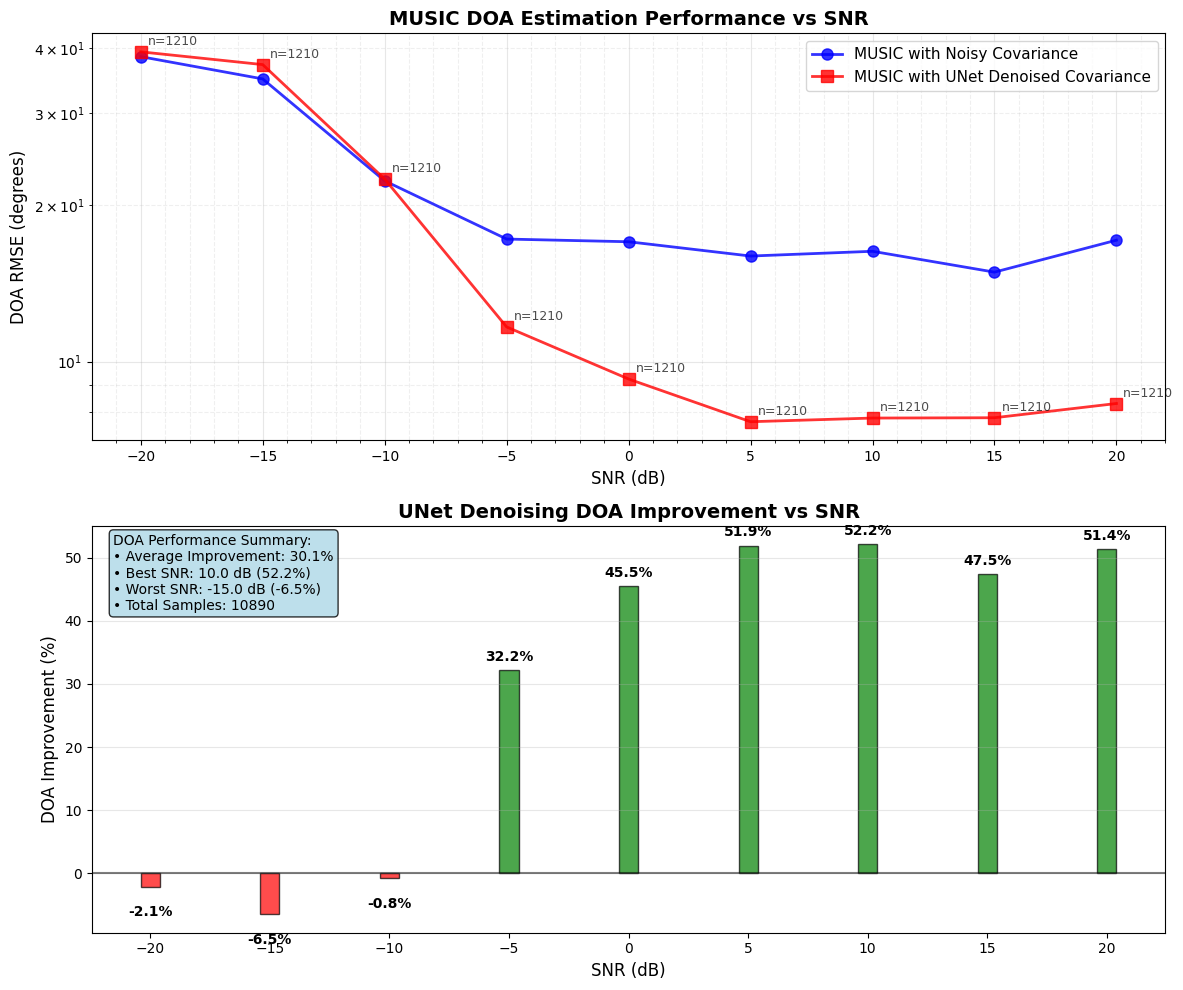


📊 DOA Performance Numerical Summary:
SNR (dB)   Noisy MUSIC     UNet MUSIC      Improvement 
           RMSE (°)        RMSE (°)        (%)         
------------------------------------------------------------
-20.0      38.52           39.34           -2.1        
-15.0      34.90           37.18           -6.5        
-10.0      22.24           22.42           -0.8        
-5.0       17.19           11.66           32.2        
0.0        16.99           9.26            45.5        
5.0        15.95           7.67            51.9        
10.0       16.29           7.79            52.2        
15.0       14.85           7.80            47.5        
20.0       17.11           8.31            51.4        

🔍 Creating detailed DOA RMSE analysis with error bars...
📁 Detailed plot saved to: unet_detailed_doa_analysis_detailed.png


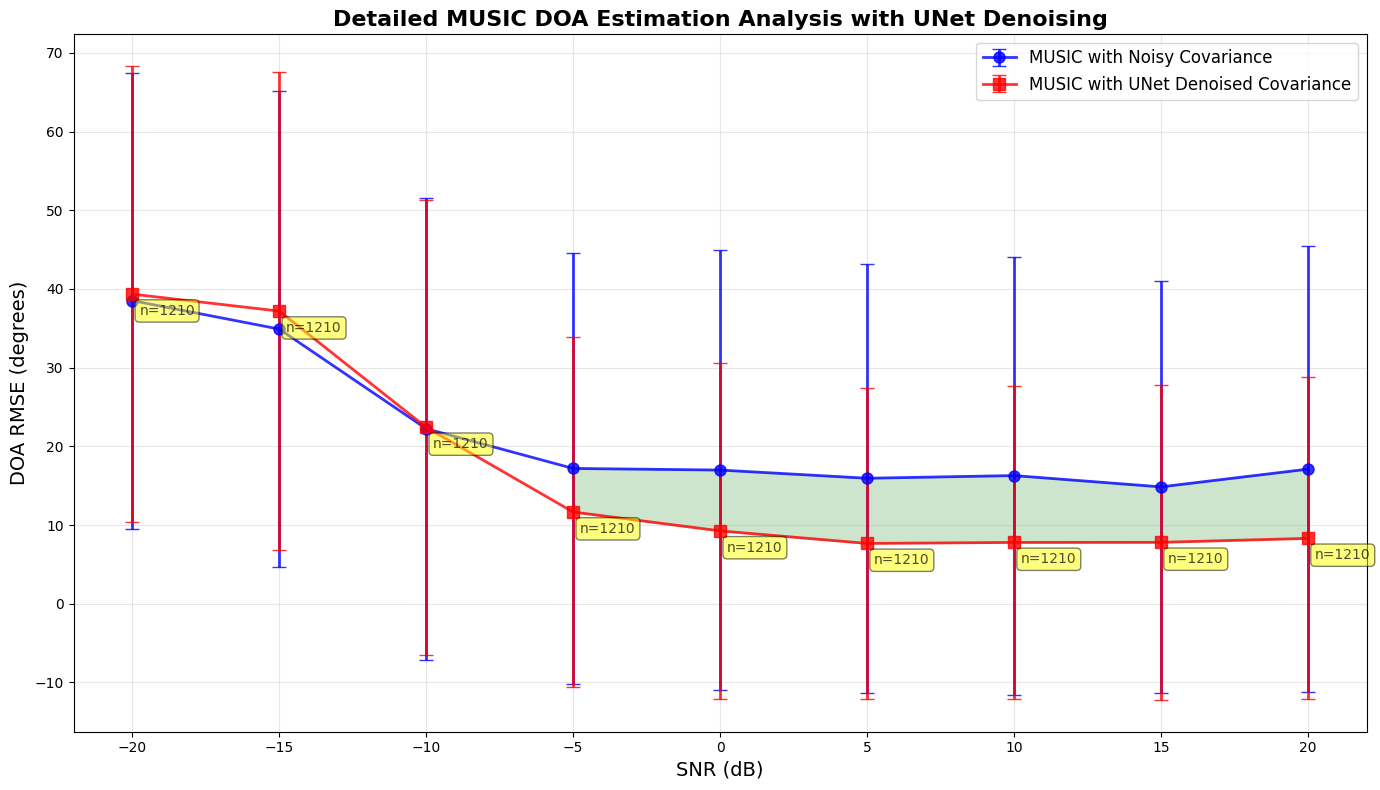


🗺️ Creating DOA improvement heatmap...


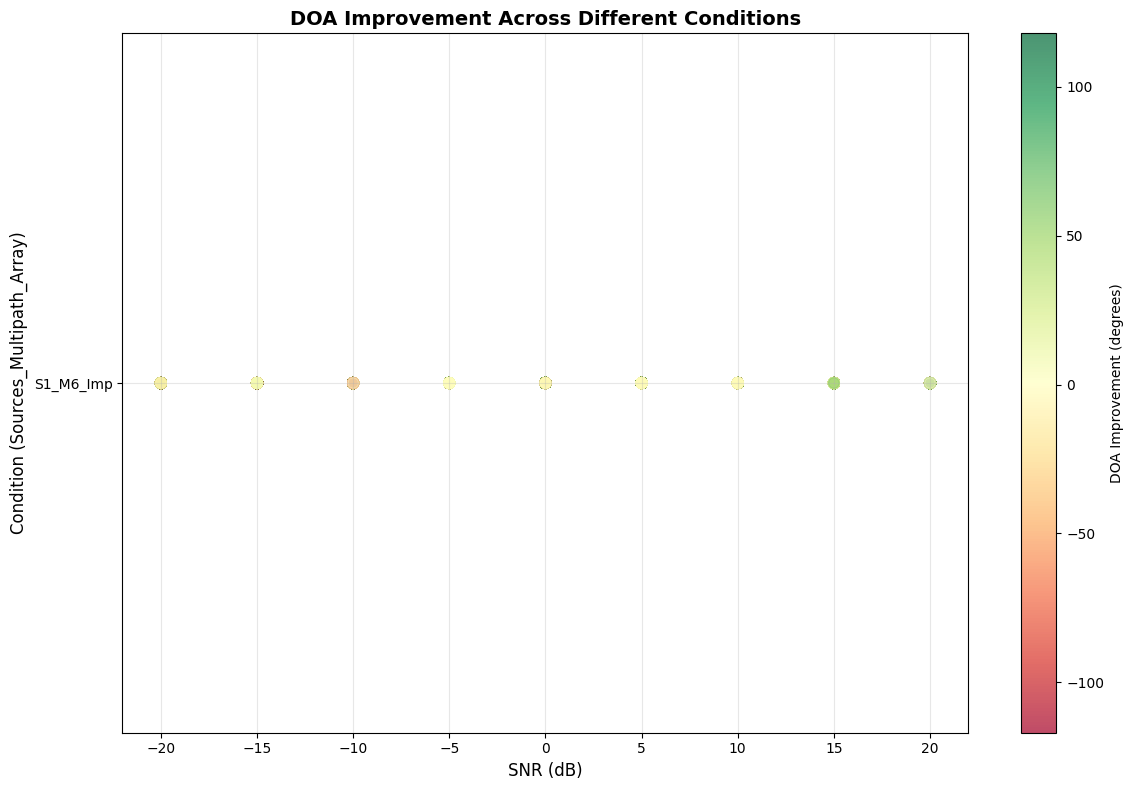


✅ All DOA performance plots generated successfully!


In [64]:
# Generate plots from DOA evaluation results
if 'evaluation_results' in locals() and evaluation_results is not None:
    print("📊 Generating DOA RMSE vs SNR plots...")
    
    # Basic DOA RMSE comparison plot
    print("\n🎯 Creating basic DOA RMSE vs SNR comparison...")
    plot_doa_rmse_vs_snr(evaluation_results, save_path="unet_doa_rmse_comparison.png")
    
    # Detailed analysis plot
    print("\n🔍 Creating detailed DOA RMSE analysis with error bars...")
    plot_detailed_doa_rmse_analysis(evaluation_results, save_path="unet_detailed_doa_analysis.png")
    
    # Improvement heatmap
    print("\n🗺️ Creating DOA improvement heatmap...")
    plot_doa_improvement_heatmap(evaluation_results)
    
    print("\n✅ All DOA performance plots generated successfully!")
    
else:
    print("❌ No evaluation results available for plotting")
    print("Please run the DOA performance evaluation first")